<a href="https://colab.research.google.com/github/Bhavanam-Gireesh-Reddy/Incremental/blob/main/Incremental_Project_Till-Day13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Path to dataset files:", path)

# Verify if the dataset was downloaded
if os.path.exists(path):
    print("Dataset downloaded successfully to:", path)
else:
    print("Dataset download failed or path does not exist.")

Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
Path to dataset files: /kaggle/input/fashion-product-images-small
Dataset downloaded successfully to: /kaggle/input/fashion-product-images-small


In [3]:
import os

# List the contents of the downloaded directory
print(f"Contents of {path}:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Streaming output truncated to the last 5000 lines.
/kaggle/input/fashion-product-images-small/images/38138.jpg
/kaggle/input/fashion-product-images-small/images/25383.jpg
/kaggle/input/fashion-product-images-small/images/45661.jpg
/kaggle/input/fashion-product-images-small/images/48569.jpg
/kaggle/input/fashion-product-images-small/images/12782.jpg
/kaggle/input/fashion-product-images-small/images/39170.jpg
/kaggle/input/fashion-product-images-small/images/55612.jpg
/kaggle/input/fashion-product-images-small/images/30616.jpg
/kaggle/input/fashion-product-images-small/images/6118.jpg
/kaggle/input/fashion-product-images-small/images/19177.jpg
/kaggle/input/fashion-product-images-small/images/43477.jpg
/kaggle/input/fashion-product-images-small/images/25346.jpg
/kaggle/input/fashion-product-images-small/images/6136.jpg
/kaggle/input/fashion-product-images-small/images/54674.jpg
/kaggle/input/fashion-product-images-small/images/51433.jpg
/kaggle/input/fashion-product-images-small/images/5

In [4]:
import shutil
import os

source_path = path # This is '/kaggle/input/fashion-product-images-small'
destination_path = '/content/fashion-product-images-small'

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_path):
    os.makedirs(destination_path)

print(f"Copying dataset from '{source_path}' to '{destination_path}'...")

try:
    # Copy the entire directory tree. dirs_exist_ok=True allows copying into an existing directory.
    # However, if the destination already contains files that are also in the source,
    # shutil.copytree will raise an error if they conflict. It's safer to delete first
    # or ensure the destination is empty before copying a full tree.
    # For this specific case, let's assume the user wants a fresh copy or the destination is empty.
    shutil.copytree(source_path, destination_path, dirs_exist_ok=True)
    print("Dataset copied successfully!")
    # Update the 'path' variable to point to the new writable location for future operations
    path = destination_path
    print(f"New dataset path for modifications: {path}")
except shutil.Error as e:
    print(f"Error during copy: {e}. This usually happens if the destination directory is not empty or conflicts exist. Please ensure '{destination_path}' is empty or remove it manually before running if you want a fresh copy.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# List contents of the new path to confirm
print(f"Contents of the new dataset location ({path}):")
for root, dirs, files in os.walk(path):
    for name in dirs:
        print(os.path.join(root, name))
    break # Only list top-level directories for brevity

Copying dataset from '/kaggle/input/fashion-product-images-small' to '/content/fashion-product-images-small'...
Dataset copied successfully!
New dataset path for modifications: /content/fashion-product-images-small
Contents of the new dataset location (/content/fashion-product-images-small):
/content/fashion-product-images-small/images
/content/fashion-product-images-small/myntradataset


In [5]:
import shutil
import os

directory_to_remove = os.path.join(path, "myntradataset")

if os.path.exists(directory_to_remove):
    print(f"Removing directory: {directory_to_remove}...")
    shutil.rmtree(directory_to_remove)
    print(f"Directory '{directory_to_remove}' removed successfully.")
else:
    print(f"Directory '{directory_to_remove}' does not exist, skipping removal.")

# List contents again to confirm removal
print(f"\nContents of the dataset location ({path}) after removal:")
for root, dirs, files in os.walk(path):
    for name in dirs:
        print(os.path.join(root, name))
    break # Only list top-level directories for brevity

Removing directory: /content/fashion-product-images-small/myntradataset...
Directory '/content/fashion-product-images-small/myntradataset' removed successfully.

Contents of the dataset location (/content/fashion-product-images-small) after removal:
/content/fashion-product-images-small/images


In [9]:
from google.colab import files

print("Please upload the zip file from your friend.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')
    friend_zip_filename = filename

Please upload the zip file from your friend.


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
User uploaded file "WA_Fn-UseC_-Telco-Customer-Churn.csv"


In [10]:
url = '/content/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)

In [11]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [16]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

print(f"Missing values in TotalCharges after imputation: {df['TotalCharges'].isnull().sum()}")
print(f"TotalCharges dtype after conversion: {df['TotalCharges'].dtype}")

Missing values in TotalCharges after imputation: 0
TotalCharges dtype after conversion: float64


/tmp/ipykernel_3748/817956655.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)


In [18]:
y = df['Churn']
X = df.drop(['Churn'], axis = 1)

In [19]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features.remove('customerID')
categorical_features.remove('Churn')

print(f"Updated Numeric Features: {numeric_features}")
print(f"Updated Categorical Features: {categorical_features}")

Updated Numeric Features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Updated Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [20]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [21]:
numerical_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])

In [22]:
categorical_pipeline = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('Oencoder', OneHotEncoder(handle_unknown = 'ignore'))
])
y = LabelEncoder().fit_transform(y)

In [23]:
y

array([0, 0, 1, ..., 0, 1, 0])

In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

In [26]:
pipelines = {
    'LogisticRegression': Pipeline(steps = [('preprocess', preprocessor), ('classifier', LogisticRegression(max_iter=1000))]),
    'KNeighborsClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', KNeighborsClassifier())]),
    # 'MultinomialNB': Pipeline(steps = [('preprocess', preprocessor), ('classifier', MultinomialNB())]), # Note: MultinomialNB needs non-negative features. One-hot encoding produces this.
    # 'GaussianNB': Pipeline(steps = [('preprocess', preprocessor), ('classifier', GaussianNB())]),
    'DecisionTreeClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', DecisionTreeClassifier())]),
    'SVC': Pipeline(steps = [('preprocess', preprocessor), ('classifier', SVC())]),
    'RandomForestClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', RandomForestClassifier())]),
    'GradientBoostingClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', GradientBoostingClassifier())]),
    'AdaBoostClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', AdaBoostClassifier())]),
    'XGBoostClassifier': Pipeline(steps = [('preprocess', preprocessor), ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))])
}

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, shuffle = True)

In [28]:
fitted_models = {}
for name, pipeline in pipelines.items():
    print(f"Fitting {name}...")
    fitted_models[name] = pipeline.fit(X_train, y_train)
    print(f"{name} fitted.")

Fitting LogisticRegression...
LogisticRegression fitted.
Fitting KNeighborsClassifier...
KNeighborsClassifier fitted.
Fitting DecisionTreeClassifier...
DecisionTreeClassifier fitted.
Fitting SVC...
SVC fitted.
Fitting RandomForestClassifier...
RandomForestClassifier fitted.
Fitting GradientBoostingClassifier...
GradientBoostingClassifier fitted.
Fitting AdaBoostClassifier...
AdaBoostClassifier fitted.
Fitting XGBoostClassifier...
XGBoostClassifier fitted.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:54:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [29]:
results = {}
for name, model in fitted_models.items():
    print(f"Evaluating {name}...")
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1Score = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracy:.4f}")
    print(f"Precision for {name}: {precision:.4f}")
    print(f"Recall for {name}: {recall:.4f}")
    print(f"F1 Score for {name}: {f1Score:.4f}")
    print(f"ROC AUC Score for {name}: {roc_auc:.4f}")
    print(f"Confusion Matrix for {name}:\n{cm}\n")
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}\n")
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1Score': f1Score,
        'roc_auc': roc_auc,
        'y_pred': y_pred
    }

Evaluating LogisticRegression...
Accuracy for LogisticRegression: 0.8183
Precision for LogisticRegression: 0.6757
Recall for LogisticRegression: 0.6032
F1 Score for LogisticRegression: 0.6374
ROC AUC Score for LogisticRegression: 0.7495
Confusion Matrix for LogisticRegression:
[[928 108]
 [148 225]]

Classification Report for LogisticRegression:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409


Evaluating KNeighborsClassifier...
Accuracy for KNeighborsClassifier: 0.7771
Precision for KNeighborsClassifier: 0.5826
Recall for KNeighborsClassifier: 0.5576
F1 Score for KNeighborsClassifier: 0.5699
ROC AUC Score for KNeighborsClassifier: 0.7069
Confusion Matrix for KNeighborsClassifier:
[[887 149]
 [165 208]]

Classifi

In [30]:
model_comparison = pd.DataFrame({
    'Model': [name for name in results.keys()],
    'Accuracy': [metrics['accuracy'] for metrics in results.values()],
    'Precision': [metrics['precision'] for metrics in results.values()],
    'Recall': [metrics['recall'] for metrics in results.values()],
    'F1 Score': [metrics['f1Score'] for metrics in results.values()],
})
model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.818311,0.675676,0.603217,0.637394
1,SVC,0.813343,0.693662,0.528150,0.599696
2,AdaBoostClassifier,0.809794,0.661538,0.576408,0.616046
3,GradientBoostingClassifier,0.807665,0.672297,0.533512,0.594918
4,XGBoostClassifier,0.796309,0.644295,0.514745,0.572280
5,RandomForestClassifier,0.787793,0.633094,0.471850,0.540707
6,KNeighborsClassifier,0.777147,0.582633,0.557641,0.569863
7,DecisionTreeClassifier,0.707594,0.450382,0.474531,0.462141


In [31]:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5, 10]
}

dt_param_grid = {
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']
}

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 1.0]
}

lr_param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__penalty': ['l1', 'l2']
}

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

svc_param_grid = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
}

gb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__max_depth': [3, 5]
}

ada_param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__learning_rate': [0.01, 0.1, 1]
}

In [32]:
print("Starting GridSearchCV for RandomForestClassifier...")
rf_grid_search = GridSearchCV(pipelines['RandomForestClassifier'], rf_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
rf_grid_search.fit(X_train, y_train)

print(f"Best parameters for RandomForestClassifier (GridSearchCV): {rf_grid_search.best_params_}")
print(f"Best accuracy for RandomForestClassifier (GridSearchCV): {rf_grid_search.best_score_:.4f}")


rf_best_model_grid = rf_grid_search.best_estimator_

y_pred_rf_grid = rf_best_model_grid.predict(X_test)
accuracy_rf_grid = accuracy_score(y_test, y_pred_rf_grid)
precision_rf_grid = precision_score(y_test, y_pred_rf_grid)
recall_rf_grid = recall_score(y_test, y_pred_rf_grid)
f1Score_rf_grid = f1_score(y_test, y_pred_rf_grid)
roc_auc_rf_grid = roc_auc_score(y_test, y_pred_rf_grid)

results['RandomForest_GridSearchCV'] = {
    'accuracy': accuracy_rf_grid,
    'precision': precision_rf_grid,
    'recall': recall_rf_grid,
    'f1Score': f1Score_rf_grid,
    'roc_auc': roc_auc_rf_grid,
    'y_pred': y_pred_rf_grid
}

print(f"Accuracy for Tuned RandomForestClassifier (GridSearchCV): {accuracy_rf_grid:.4f}")

Starting GridSearchCV for RandomForestClassifier...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters for RandomForestClassifier (GridSearchCV): {'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}
Best accuracy for RandomForestClassifier (GridSearchCV): 0.8048
Accuracy for Tuned RandomForestClassifier (GridSearchCV): 0.8105


In [33]:
print("Starting GridSearchCV for DecisionTreeClassifier...")
dt_grid_search = GridSearchCV(pipelines['DecisionTreeClassifier'], dt_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
dt_grid_search.fit(X_train, y_train)

print(f"Best parameters for DecisionTreeClassifier (GridSearchCV): {dt_grid_search.best_params_}")
print(f"Best accuracy for DecisionTreeClassifier (GridSearchCV): {dt_grid_search.best_score_:.4f}")

dt_best_model_grid = dt_grid_search.best_estimator_

y_pred_dt_grid = dt_best_model_grid.predict(X_test)
accuracy_dt_grid = accuracy_score(y_test, y_pred_dt_grid)
precision_dt_grid = precision_score(y_test, y_pred_dt_grid)
recall_dt_grid = recall_score(y_test, y_pred_dt_grid)
f1Score_dt_grid = f1_score(y_test, y_pred_dt_grid)
roc_auc_dt_grid = roc_auc_score(y_test, y_pred_dt_grid)

results['DecisionTree_GridSearchCV'] = {
    'accuracy': accuracy_dt_grid,
    'precision': precision_dt_grid,
    'recall': recall_dt_grid,
    'f1Score': f1Score_dt_grid,
    'roc_auc': roc_auc_dt_grid,
    'y_pred': y_pred_dt_grid
}

print(f"Accuracy for Tuned DecisionTreeClassifier (GridSearchCV): {accuracy_dt_grid:.4f}")

Starting GridSearchCV for DecisionTreeClassifier...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best parameters for DecisionTreeClassifier (GridSearchCV): {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5}
Best accuracy for DecisionTreeClassifier (GridSearchCV): 0.7872
Accuracy for Tuned DecisionTreeClassifier (GridSearchCV): 0.7991


In [34]:
print("Starting GridSearchCV for XGBoostClassifier...")
xgb_grid_search = GridSearchCV(pipelines['XGBoostClassifier'], xgb_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid_search.fit(X_train, y_train)

print(f"Best parameters for XGBoostClassifier (GridSearchCV): {xgb_grid_search.best_params_}")
print(f"Best accuracy for XGBoostClassifier (GridSearchCV): {xgb_grid_search.best_score_:.4f}")

xgb_best_model_grid = xgb_grid_search.best_estimator_

y_pred_xgb_grid = xgb_best_model_grid.predict(X_test)
accuracy_xgb_grid = accuracy_score(y_test, y_pred_xgb_grid)
precision_xgb_grid = precision_score(y_test, y_pred_xgb_grid)
recall_xgb_grid = recall_score(y_test, y_pred_xgb_grid)
f1Score_xgb_grid = f1_score(y_test, y_pred_xgb_grid)
roc_auc_xgb_grid = roc_auc_score(y_test, y_pred_xgb_grid)

results['XGBoost_GridSearchCV'] = {
    'accuracy': accuracy_xgb_grid,
    'precision': precision_xgb_grid,
    'recall': recall_xgb_grid,
    'f1Score': f1Score_xgb_grid,
    'roc_auc': roc_auc_xgb_grid,
    'y_pred': y_pred_xgb_grid
}

print(f"Accuracy for Tuned XGBoostClassifier (GridSearchCV): {accuracy_xgb_grid:.4f}")

Starting GridSearchCV for XGBoostClassifier...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters for XGBoostClassifier (GridSearchCV): {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.7}
Best accuracy for XGBoostClassifier (GridSearchCV): 0.8042
Accuracy for Tuned XGBoostClassifier (GridSearchCV): 0.8062


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:02:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [35]:
hyperparameters = {}

for name, moedl in pipelines.items():
  parameters = model.get_params()
  hyperparameters[name] = parameters

In [36]:
print("Starting GridSearchCV for LogisticRegression...")
lr_grid_search = GridSearchCV(pipelines['LogisticRegression'], lr_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
lr_grid_search.fit(X_train, y_train)

print(f"Best parameters for LogisticRegression (GridSearchCV): {lr_grid_search.best_params_}")
print(f"Best accuracy for LogisticRegression (GridSearchCV): {lr_grid_search.best_score_:.4f}")

lr_best_model_grid = lr_grid_search.best_estimator_

y_pred_lr_grid = lr_best_model_grid.predict(X_test)
accuracy_lr_grid = accuracy_score(y_test, y_pred_lr_grid)
precision_lr_grid = precision_score(y_test, y_pred_lr_grid)
recall_lr_grid = recall_score(y_test, y_pred_lr_grid)
f1Score_lr_grid = f1_score(y_test, y_pred_lr_grid)
roc_auc_lr_grid = roc_auc_score(y_test, y_pred_lr_grid)

results['LogisticRegression_GridSearchCV'] = {
    'accuracy': accuracy_lr_grid,
    'precision': precision_lr_grid,
    'recall': recall_lr_grid,
    'f1Score': f1Score_lr_grid,
    'roc_auc': roc_auc_lr_grid,
    'y_pred': y_pred_lr_grid
}

print(f"Accuracy for Tuned LogisticRegression (GridSearchCV): {accuracy_lr_grid:.4f}")

Starting GridSearchCV for LogisticRegression...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters for LogisticRegression (GridSearchCV): {'classifier__C': 1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best accuracy for LogisticRegression (GridSearchCV): 0.8010
Accuracy for Tuned LogisticRegression (GridSearchCV): 0.8190


In [37]:
print("Starting GridSearchCV for KNeighborsClassifier...")
knn_grid_search = GridSearchCV(pipelines['KNeighborsClassifier'], knn_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
knn_grid_search.fit(X_train, y_train)

print(f"Best parameters for KNeighborsClassifier (GridSearchCV): {knn_grid_search.best_params_}")
print(f"Best accuracy for KNeighborsClassifier (GridSearchCV): {knn_grid_search.best_score_:.4f}")

knn_best_model_grid = knn_grid_search.best_estimator_

y_pred_knn_grid = knn_best_model_grid.predict(X_test)
accuracy_knn_grid = accuracy_score(y_test, y_pred_knn_grid)
precision_knn_grid = precision_score(y_test, y_pred_knn_grid)
recall_knn_grid = recall_score(y_test, y_pred_knn_grid)
f1Score_knn_grid = f1_score(y_test, y_pred_knn_grid)
roc_auc_knn_grid = roc_auc_score(y_test, y_pred_knn_grid)

results['KNeighborsClassifier_GridSearchCV'] = {
    'accuracy': accuracy_knn_grid,
    'precision': precision_knn_grid,
    'recall': recall_knn_grid,
    'f1Score': f1Score_knn_grid,
    'roc_auc': roc_auc_knn_grid,
    'y_pred': y_pred_knn_grid
}

print(f"Accuracy for Tuned KNeighborsClassifier (GridSearchCV): {accuracy_knn_grid:.4f}")

Starting GridSearchCV for KNeighborsClassifier...
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters for KNeighborsClassifier (GridSearchCV): {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}
Best accuracy for KNeighborsClassifier (GridSearchCV): 0.7794
Accuracy for Tuned KNeighborsClassifier (GridSearchCV): 0.7892


In [38]:
print("Starting GridSearchCV for SVC...")
svc_grid_search = GridSearchCV(pipelines['SVC'], svc_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
svc_grid_search.fit(X_train, y_train)

print(f"Best parameters for SVC (GridSearchCV): {svc_grid_search.best_params_}")
print(f"Best accuracy for SVC (GridSearchCV): {svc_grid_search.best_score_:.4f}")

svc_best_model_grid = svc_grid_search.best_estimator_

y_pred_svc_grid = svc_best_model_grid.predict(X_test)
accuracy_svc_grid = accuracy_score(y_test, y_pred_svc_grid)
precision_svc_grid = precision_score(y_test, y_pred_svc_grid)
recall_svc_grid = recall_score(y_test, y_pred_svc_grid)
f1Score_svc_grid = f1_score(y_test, y_pred_svc_grid)
roc_auc_svc_grid = roc_auc_score(y_test, y_pred_svc_grid)

results['SVC_GridSearchCV'] = {
    'accuracy': accuracy_svc_grid,
    'precision': precision_svc_grid,
    'recall': recall_svc_grid,
    'f1Score': f1Score_svc_grid,
    'roc_auc': roc_auc_svc_grid,
    'y_pred': y_pred_svc_grid
}

print(f"Accuracy for Tuned SVC (GridSearchCV): {accuracy_svc_grid:.4f}")

Starting GridSearchCV for SVC...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for SVC (GridSearchCV): {'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best accuracy for SVC (GridSearchCV): 0.8000
Accuracy for Tuned SVC (GridSearchCV): 0.8133


In [39]:
print("Starting GridSearchCV for GradientBoostingClassifier...")
gb_grid_search = GridSearchCV(pipelines['GradientBoostingClassifier'], gb_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
gb_grid_search.fit(X_train, y_train)

print(f"Best parameters for GradientBoostingClassifier (GridSearchCV): {gb_grid_search.best_params_}")
print(f"Best accuracy for GradientBoostingClassifier (GridSearchCV): {gb_grid_search.best_score_:.4f}")

gb_best_model_grid = gb_grid_search.best_estimator_

y_pred_gb_grid = gb_best_model_grid.predict(X_test)
accuracy_gb_grid = accuracy_score(y_test, y_pred_gb_grid)
precision_gb_grid = precision_score(y_test, y_pred_gb_grid)
recall_gb_grid = recall_score(y_test, y_pred_gb_grid)
f1Score_gb_grid = f1_score(y_test, y_pred_gb_grid)
roc_auc_gb_grid = roc_auc_score(y_test, y_pred_gb_grid)

results['GradientBoostingClassifier_GridSearchCV'] = {
    'accuracy': accuracy_gb_grid,
    'precision': precision_gb_grid,
    'recall': recall_gb_grid,
    'f1Score': f1Score_gb_grid,
    'roc_auc': roc_auc_gb_grid,
    'y_pred': y_pred_gb_grid
}

print(f"Accuracy for Tuned GradientBoostingClassifier (GridSearchCV): {accuracy_gb_grid:.4f}")

Starting GridSearchCV for GradientBoostingClassifier...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters for GradientBoostingClassifier (GridSearchCV): {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Best accuracy for GradientBoostingClassifier (GridSearchCV): 0.8012
Accuracy for Tuned GradientBoostingClassifier (GridSearchCV): 0.8105


In [40]:
print("Starting GridSearchCV for AdaBoostClassifier...")
ada_grid_search = GridSearchCV(pipelines['AdaBoostClassifier'], ada_param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
ada_grid_search.fit(X_train, y_train)

print(f"Best parameters for AdaBoostClassifier (GridSearchCV): {ada_grid_search.best_params_}")
print(f"Best accuracy for AdaBoostClassifier (GridSearchCV): {ada_grid_search.best_score_:.4f}")

ada_best_model_grid = ada_grid_search.best_estimator_

y_pred_ada_grid = ada_best_model_grid.predict(X_test)
accuracy_ada_grid = accuracy_score(y_test, y_pred_ada_grid)
precision_ada_grid = precision_score(y_test, y_pred_ada_grid)
recall_ada_grid = recall_score(y_test, y_pred_ada_grid)
f1Score_ada_grid = f1_score(y_test, y_pred_ada_grid)
roc_auc_ada_grid = roc_auc_score(y_test, y_pred_ada_grid)

results['AdaBoostClassifier_GridSearchCV'] = {
    'accuracy': accuracy_ada_grid,
    'precision': precision_ada_grid,
    'recall': recall_ada_grid,
    'f1Score': f1Score_ada_grid,
    'roc_auc': roc_auc_ada_grid,
    'y_pred': y_pred_ada_grid
}

print(f"Accuracy for Tuned AdaBoostClassifier (GridSearchCV): {accuracy_ada_grid:.4f}")

Starting GridSearchCV for AdaBoostClassifier...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters for AdaBoostClassifier (GridSearchCV): {'classifier__learning_rate': 1, 'classifier__n_estimators': 100}
Best accuracy for AdaBoostClassifier (GridSearchCV): 0.7996
Accuracy for Tuned AdaBoostClassifier (GridSearchCV): 0.8105


In [41]:
final_model_comparison = pd.DataFrame({
    'Model': [name for name in results.keys()],
    'Accuracy': [metrics['accuracy'] for metrics in results.values()],
    'Precision': [metrics['precision'] for metrics in results.values()],
    'Recall': [metrics['recall'] for metrics in results.values()],
    'F1 Score': [metrics['f1Score'] for metrics in results.values()],
    'ROC AUC Score': [metrics['roc_auc'] for metrics in results.values()]
})
final_model_comparison = final_model_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,LogisticRegression_GridSearchCV,0.819021,0.678788,0.600536,0.637269,0.749110
1,LogisticRegression,0.818311,0.675676,0.603217,0.637394,0.749485
2,SVC_GridSearchCV,0.813343,0.693662,0.528150,0.599696,0.722087
3,SVC,0.813343,0.693662,0.528150,0.599696,0.722087
4,RandomForest_GridSearchCV,0.810504,0.685315,0.525469,0.594841,0.719298
5,GradientBoostingClassifier_GridSearchCV,0.810504,0.686620,0.522788,0.593607,0.718440
6,AdaBoostClassifier_GridSearchCV,0.810504,0.662577,0.579088,0.618026,0.736455
7,AdaBoostClassifier,0.809794,0.661538,0.576408,0.616046,0.735115
8,GradientBoostingClassifier,0.807665,0.672297,0.533512,0.594918,0.719941
9,XGBoost_GridSearchCV,0.806246,0.665563,0.538874,0.595556,0.720692


In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

print("Applying preprocessor to X_train and X_test...")
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"Shape of preprocessed X_train: {X_train_preprocessed.shape}")
print(f"Shape of preprocessed X_test: {X_test_preprocessed.shape}")

Applying preprocessor to X_train and X_test...
Shape of preprocessed X_train: (5634, 44)
Shape of preprocessed X_test: (1409, 44)


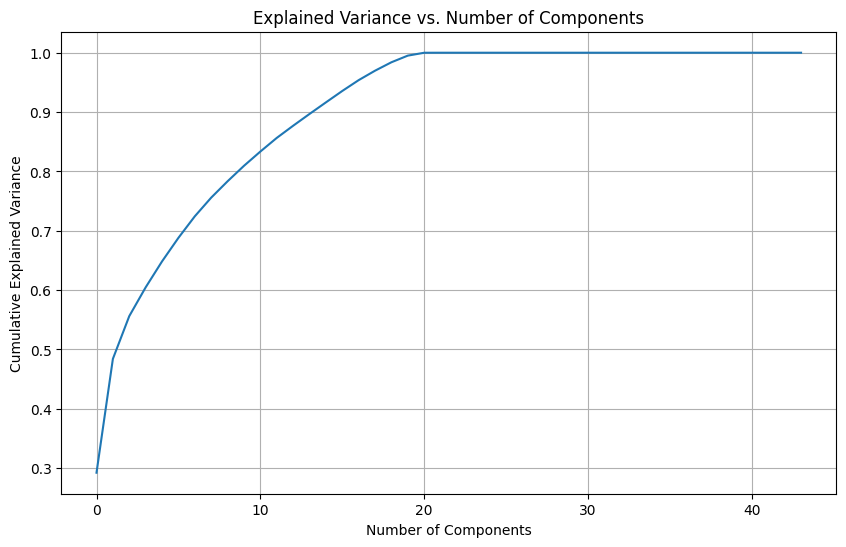

Number of components to explain 95% variance: 17
Shape of X_train after PCA: (5634, 17)
Shape of X_test after PCA: (1409, 17)


In [43]:
pca = PCA()
pca.fit(X_train_preprocessed)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

explained_variance_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
print(f"Number of components to explain 95% variance: {explained_variance_95}")

pca_final = PCA(n_components=explained_variance_95)
X_train_pca = pca_final.fit_transform(X_train_preprocessed)
X_test_pca = pca_final.transform(X_test_preprocessed)

print(f"Shape of X_train after PCA: {X_train_pca.shape}")
print(f"Shape of X_test after PCA: {X_test_pca.shape}")

In [44]:
print("\nEigenvalues (Explained Variance):")
display(pd.DataFrame({'Eigenvalue': pca.explained_variance_}).T)

print("\nEigenvectors (Principal Components):\n(Each row is a principal component, ordered by explained variance)")
display(pd.DataFrame(pca.components_))


Eigenvalues (Explained Variance):


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
Eigenvalue,3.350327,2.199929,0.825955,0.555672,0.501524,0.454982,0.416136,0.36053,0.316201,0.298545,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Eigenvectors (Principal Components):
(Each row is a principal component, ordered by explained variance)


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,3.237996e-01,4.914976e-01,4.755852e-01,0.003887,-0.003887,-0.071070,0.071070,0.005275,-0.005275,-0.008918,...,0.169664,-0.054382,0.020474,0.033908,-0.091322,0.091322,0.031306,0.028286,0.038020,-0.097612
1,4.779465e-01,-1.915566e-01,2.825437e-01,0.000377,-0.000377,-0.133806,0.133806,-0.105506,0.105506,-0.016302,...,0.005495,-0.246768,0.065903,0.180865,0.097357,-0.097357,0.051225,0.061853,-0.139487,0.026409
2,1.406241e-01,-2.781447e-01,-3.115767e-02,-0.016557,0.016557,-0.078969,0.078969,-0.109096,0.109096,0.189592,...,-0.106798,-0.099986,0.039650,0.060335,0.119233,-0.119233,0.038341,0.054633,-0.120343,0.027369
3,9.718706e-02,-5.472287e-02,9.125060e-02,0.013717,-0.013717,0.494363,-0.494363,0.434132,-0.434132,0.065470,...,0.060950,-0.064249,0.038524,0.025726,0.042509,-0.042509,0.018293,0.016021,-0.060032,0.025718
4,-5.331151e-02,2.273108e-02,-2.165667e-02,0.700567,-0.700567,-0.019089,0.019089,-0.016652,0.016652,-0.005762,...,0.009524,0.002616,-0.006198,0.003582,-0.008326,0.008326,0.007237,-0.000793,-0.022810,0.016366
5,3.608492e-01,-1.671722e-01,1.170870e-01,0.060871,-0.060871,0.029054,-0.029054,0.139955,-0.139955,-0.041510,...,-0.316765,0.040658,-0.062448,0.021790,-0.124796,0.124796,0.049905,0.025587,0.018282,-0.093773
6,-7.574539e-02,2.338100e-01,8.697172e-02,-0.018249,0.018249,0.045228,-0.045228,0.006288,-0.006288,-0.231372,...,-0.144848,-0.015367,0.022130,-0.006763,0.482138,-0.482138,0.021154,-0.002048,-0.110967,0.091861
7,4.176638e-02,-5.664537e-02,-4.853904e-02,0.054082,-0.054082,-0.048854,0.048854,0.041765,-0.041765,0.141158,...,0.123952,0.031627,-0.055188,0.023561,0.441275,-0.441275,-0.010726,-0.033978,0.118770,-0.074066
8,2.080972e-01,-3.452630e-02,4.808880e-02,0.027455,-0.027455,-0.001903,0.001903,0.045570,-0.045570,-0.070403,...,-0.025727,-0.114951,0.049615,0.065337,-0.066547,0.066547,0.066309,0.059076,-0.057180,-0.068205
9,-2.376060e-01,9.245847e-02,-8.115938e-02,-0.016055,0.016055,0.063167,-0.063167,-0.087124,0.087124,-0.048460,...,-0.053599,0.072048,-0.145104,0.073056,-0.096275,0.096275,-0.016966,0.015924,-0.118317,0.119360


In [45]:
print("\nCovariance Matrix of the preprocessed training data:")
display(pd.DataFrame(pca.get_covariance()))


Covariance Matrix of the preprocessed training data:


,0,1,2,3,4,5,6,7,8,9,...,34,35,36,37,38,39,40,41,42,43
0,1.000178,0.253848,0.826584,-0.000341,0.000341,-0.189425,0.189425,-0.074268,0.074268,-0.001933,...,0.141965,-0.318818,0.083512,0.235307,-0.004016,0.004016,0.093545,0.098031,-0.094664,-0.096912
1,0.253848,1.000178,0.652892,0.009142,-0.009142,-0.052889,0.052889,0.051648,-0.051648,-0.074283,...,0.306397,0.028910,0.001356,-0.030267,-0.175238,0.175238,0.021629,0.010568,0.126559,-0.158757
2,0.826584,0.652892,1.000178,0.003130,-0.003130,-0.161124,0.161124,-0.030327,0.030327,-0.034031,...,0.254610,-0.221190,0.069792,0.151398,-0.080232,0.080232,0.074599,0.074856,-0.026404,-0.123051
3,-0.000341,0.009142,0.003130,0.249890,-0.249890,-0.001761,0.001761,0.002235,-0.002235,-0.001623,...,0.002272,0.000498,-0.002120,0.001622,-0.003872,0.003872,0.002376,0.000132,-0.001785,-0.000723
4,0.000341,-0.009142,-0.003130,-0.249890,0.249890,0.001761,-0.001761,-0.002235,0.002235,0.001623,...,-0.002272,-0.000498,0.002120,-0.001622,0.003872,-0.003872,-0.002376,-0.000132,0.001785,0.000723
5,-0.189425,-0.052889,-0.161124,-0.001761,0.001761,0.249806,-0.249806,0.103051,-0.103051,0.004345,...,-0.028125,0.070281,-0.017525,-0.052756,-0.004111,0.004111,-0.019904,-0.020495,0.020124,0.020274
6,0.189425,0.052889,0.161124,0.001761,-0.001761,-0.249806,0.249806,-0.103051,0.103051,-0.004345,...,0.028125,-0.070281,0.017525,0.052756,0.004111,-0.004111,0.019904,0.020495,-0.020124,-0.020274
7,-0.074268,0.051648,-0.030327,0.002235,-0.002235,0.103051,-0.103051,0.209524,-0.209524,0.000336,...,0.007508,0.052363,-0.012240,-0.040123,-0.023833,0.023833,-0.006956,-0.014818,0.033142,-0.011368
8,0.074268,-0.051648,0.030327,-0.002235,0.002235,-0.103051,0.103051,-0.209524,0.209524,-0.000336,...,-0.007508,-0.052363,0.012240,0.040123,0.023833,-0.023833,0.006956,0.014818,-0.033142,0.011368
9,-0.001933,-0.074283,-0.034031,-0.001623,0.001623,0.004345,-0.004345,0.000336,-0.000336,0.088393,...,0.004215,-0.000366,0.001110,-0.000744,0.002622,-0.002622,-0.000762,0.001914,-0.000334,-0.000818


In [46]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [47]:
# from tensorflow.keras import regularizers

model = Sequential([
    Dense(128, activation = 'relu', input_shape = (X_train_pca.shape[1],)),# kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    Dense(64, activation = 'relu'),
    layers.Dropout(0.3),
    Dense(1, activation = 'sigmoid')
])

model.compile(optimizer = 'adam', loss = tf.keras.losses.BinaryCrossentropy(), metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_pca, y_train, epochs = 50, batch_size = 32, validation_split = 0.2, callbacks=[early_stopping])

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.7628 - loss: 0.4777 - val_accuracy: 0.8066 - val_loss: 0.4222
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7886 - loss: 0.4410 - val_accuracy: 0.8030 - val_loss: 0.4190
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7899 - loss: 0.4375 - val_accuracy: 0.8066 - val_loss: 0.4187
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7948 - loss: 0.4342 - val_accuracy: 0.7995 - val_loss: 0.4172
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7965 - loss: 0.4314 - val_accuracy: 0.8083 - val_loss: 0.4141
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7950 - loss: 0.4279 - val_accuracy: 0.8083 - val_loss: 0.4127
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8001 - loss: 0.4263 - val_accuracy: 0.8075 - val_loss: 0.4162
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7976 - loss: 0.4277 - val_accuracy: 0

In [50]:
model.evaluate(X_test_pca, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8098 - loss: 0.4076


[0.40761953592300415, 0.8097941875457764]

In [51]:
y_pred = model.predict(X_test_pca)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [52]:
ypred = (y_pred > 0.5).astype(int).flatten()

In [53]:
accuracy_ANN = accuracy_score(y_test, ypred)

In [54]:
print(f"Accuracy of ANN: {accuracy_ANN}")

Accuracy of ANN: 0.8097941802696949


### ANN Model Evaluation and Learning Curves

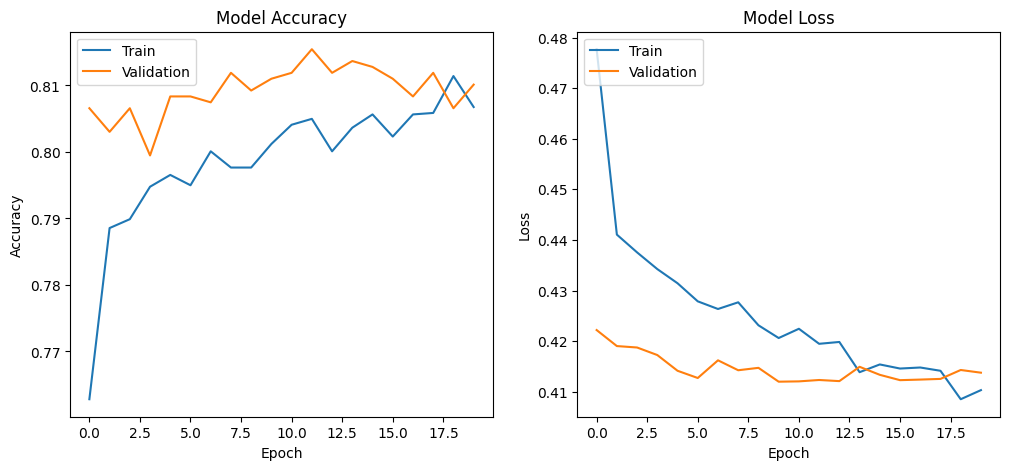

In [55]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [56]:
print('Classification Report for ANN:')
print(classification_report(y_test, ypred))

print('Confusion Matrix for ANN:')
print(confusion_matrix(y_test, ypred))

Classification Report for ANN:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix for ANN:
[[940  96]
 [172 201]]


In [57]:
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D

In [58]:
data = "/content/fashion-product-images-small/images"

In [59]:
import pandas as pd
import os

styles_file_path = os.path.join(path, "styles.csv")

df = pd.read_csv(styles_file_path, on_bad_lines='skip')

display(df.head())

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [60]:
import numpy as np

# Ensure the 'id' column in the DataFrame is in a format that matches image filenames
# Image filenames are typically 'id.jpg'
df['id'] = df['id'].astype(str)

# Get a list of all image file paths
image_dir = os.path.join(path, "images")
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
image_ids_in_folder = [os.path.splitext(f)[0] for f in image_files]

# Filter the DataFrame to include only images that actually exist in the folder
# This also creates a copy to avoid SettingWithCopyWarning
filtered_df = df[df['id'].isin(image_ids_in_folder)].copy()

# Add the full image path to the DataFrame
filtered_df['image_path'] = filtered_df['id'].apply(lambda x: os.path.join(image_dir, x + '.jpg'))

# Verify that all image paths actually exist
filtered_df = filtered_df[filtered_df['image_path'].apply(os.path.exists)]

print(f"Original DataFrame size: {len(df)}")
print(f"Images found in folder: {len(image_ids_in_folder)}")
print(f"Filtered DataFrame size (images with existing files): {len(filtered_df)}")

# Display the updated DataFrame with image paths and labels
display(filtered_df.head())

Original DataFrame size: 44424
Images found in folder: 44441
Filtered DataFrame size (images with existing files): 44419


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,/content/fashion-product-images-small/images/1...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,/content/fashion-product-images-small/images/3...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,/content/fashion-product-images-small/images/5...
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,/content/fashion-product-images-small/images/2...
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,/content/fashion-product-images-small/images/5...


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Choose the target label. For example, 'articleType' or 'masterCategory'
target_label = 'articleType'

# Drop rows where the target label might be missing
processed_df = filtered_df.dropna(subset=[target_label]).copy()

# Calculate the counts of each class
class_counts = processed_df[target_label].value_counts()
# Identify classes with only one sample
single_sample_classes = class_counts[class_counts < 2].index

# Filter out rows belonging to single-sample classes
processed_df = processed_df[~processed_df[target_label].isin(single_sample_classes)].copy()

# Encode the target labels
label_encoder = LabelEncoder()
processed_df['encoded_label'] = label_encoder.fit_transform(processed_df[target_label])

# Display the mapping of original labels to encoded integers
print("Label mapping (after filtering single-sample classes):")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

# Separate image paths and encoded labels
image_paths = processed_df['image_path'].values
labels = processed_df['encoded_label'].values

# Split the data into training and testing sets
# We stratify to ensure that each split has approximately the same percentage of samples of each target class
train_images, test_images, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\nTotal images (after filtering): {len(image_paths)}")
print(f"Training images: {len(train_images)}")
print(f"Test images: {len(test_images)}")
print(f"Number of unique labels (after filtering): {len(label_encoder.classes_)}")

Label mapping (after filtering single-sample classes):
Accessory Gift Set: 0
Baby Dolls: 1
Backpacks: 2
Bangle: 3
Basketballs: 4
Bath Robe: 5
Beauty Accessory: 6
Belts: 7
Blazers: 8
Body Lotion: 9
Booties: 10
Boxers: 11
Bra: 12
Bracelet: 13
Briefs: 14
Camisoles: 15
Capris: 16
Caps: 17
Casual Shoes: 18
Churidar: 19
Clothing Set: 20
Clutches: 21
Compact: 22
Concealer: 23
Cufflinks: 24
Deodorant: 25
Dresses: 26
Duffel Bag: 27
Dupatta: 28
Earrings: 29
Eye Cream: 30
Eyeshadow: 31
Face Moisturisers: 32
Face Scrub and Exfoliator: 33
Face Serum and Gel: 34
Face Wash and Cleanser: 35
Flats: 36
Flip Flops: 37
Footballs: 38
Formal Shoes: 39
Foundation and Primer: 40
Fragrance Gift Set: 41
Free Gifts: 42
Gloves: 43
Hair Colour: 44
Handbags: 45
Hat: 46
Headband: 47
Heels: 48
Highlighter and Blush: 49
Innerwear Vests: 50
Jackets: 51
Jeans: 52
Jeggings: 53
Jewellery Set: 54
Jumpsuit: 55
Kajal and Eyeliner: 56
Key chain: 57
Kurta Sets: 58
Kurtas: 59
Kurtis: 60
Laptop Bag: 61
Leggings: 62
Lehenga Choli

In [62]:
train_images.shape

(35530,)

### Image Preprocessing for CNN

In [63]:
import tensorflow as tf
import numpy as np

# Define image dimensions
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 3

def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
    return img, label

# Create TensorFlow datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
train_ds = train_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=1000).batch(32).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

print(f"Training dataset created with {len(train_images)} images.")
print(f"Test dataset created with {len(test_images)} images.")

# Example of one batch from the training dataset
for image_batch, label_batch in train_ds.take(1):
    print(f"Image batch shape: {image_batch.shape}")
    print(f"Label batch shape: {label_batch.shape}")

Training dataset created with 35530 images.
Test dataset created with 8883 images.
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


### Build and Train the CNN Model

In [64]:
from tensorflow.keras import layers, models

num_classes = len(np.unique(train_labels))

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    layers.Dropout(0.6), # Added dropout for regularization
    Dense(num_classes, activation='softmax') # Softmax for multi-class classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [65]:
model_cnn.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 136)            │        17,544 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,322,184 (12.67 MB)

 Trainable params: 3,322,184 (12.67 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
history_cnn = model_cnn.fit(
    train_ds,
    epochs=10, # You can increase this for better convergence
    validation_data=test_ds
)

Epoch 1/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - accuracy: 0.5053 - loss: 2.0162 - val_accuracy: 0.6981 - val_loss: 1.1407
Epoch 2/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.6474 - loss: 1.2979 - val_accuracy: 0.7501 - val_loss: 0.8790
Epoch 3/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.6945 - loss: 1.0872 - val_accuracy: 0.7749 - val_loss: 0.7696
Epoch 4/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.7209 - loss: 0.9652 - val_accuracy: 0.7903 - val_loss: 0.7210
Epoch 5/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.7417 - loss: 0.8659 - val_accuracy: 0.8020 - val_loss: 0.6780
Epoch 6/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.7575 - loss: 0.8006 - val_accuracy: 0.8147 - val_loss: 0.6575
Epoch 7/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.7720 - loss: 0.7352 - val_accuracy: 0.8104 - val_loss: 0.6738
Epoch 8/10
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.7843 -

### Evaluate the CNN Model and Visualize Learning Curves

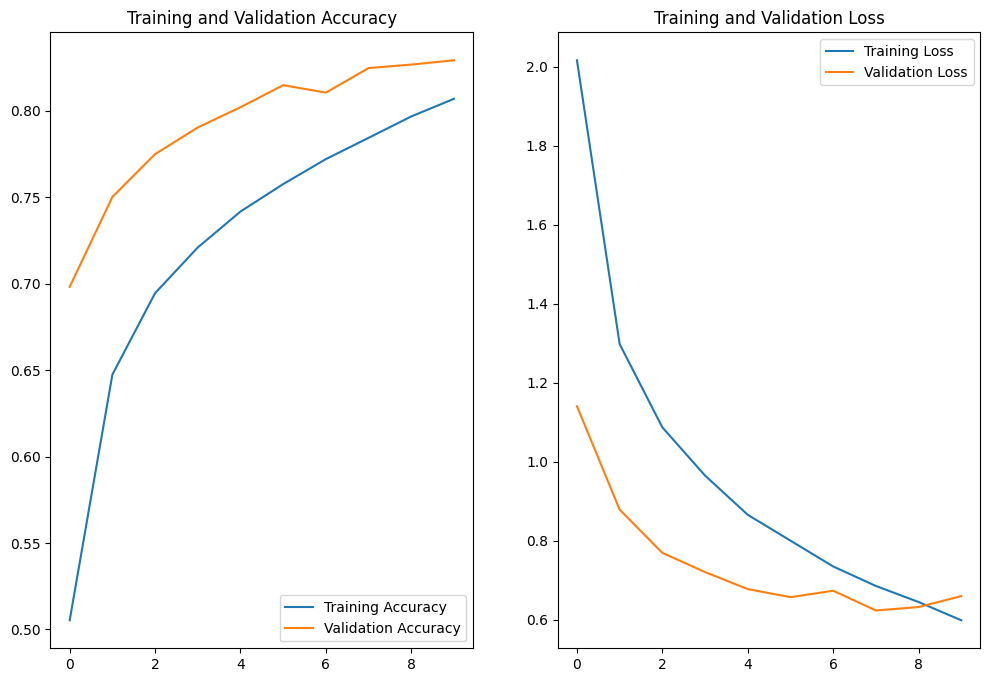

In [67]:
import matplotlib.pyplot as plt

acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']

loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [68]:
loss, accuracy = model_cnn.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8291 - loss: 0.6601
Test Loss: 0.6601
Test Accuracy: 0.8291


In [69]:
y_pred = model_cnn.predict(test_ds)

278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [70]:
import numpy as np
ypred = np.argmax(y_pred, axis = 1)
accuracy_cnn = accuracy_score(test_labels, ypred)
print(f"Accuracy of CNN: {accuracy_cnn}")

Accuracy of CNN: 0.8291117865585951


In [71]:
from tensorflow.keras import applications

In [72]:
base_model = applications.ResNet50V2(weights = 'imagenet', include_top = False, input_shape = (160, 160, 3))

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [73]:
base_model.trainable = False

In [74]:
model_T = Sequential([
    layers.Lambda(lambda image: tf.image.resize(image, (160, 160))),
    # layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation = 'softmax')
])

In [75]:
model_T.compile(optimizer = 'adam', loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), metrics = ['accuracy'])

In [76]:
model_T.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 5, 5, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,564,800 (89.89 MB)

In [77]:
history_T = model_T.fit(
    train_ds,
    epochs=15,
    validation_data=test_ds)

Epoch 1/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 93s 72ms/step - accuracy: 0.6371 - loss: 1.4114 - val_accuracy: 0.7531 - val_loss: 0.8262
Epoch 2/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 66s 59ms/step - accuracy: 0.7244 - loss: 0.9458 - val_accuracy: 0.7756 - val_loss: 0.7297
Epoch 3/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 65s 58ms/step - accuracy: 0.7472 - loss: 0.8299 - val_accuracy: 0.7917 - val_loss: 0.6726
Epoch 4/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 65s 58ms/step - accuracy: 0.7637 - loss: 0.7565 - val_accuracy: 0.7959 - val_loss: 0.6542
Epoch 5/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 65s 58ms/step - accuracy: 0.7745 - loss: 0.7114 - val_accuracy: 0.7998 - val_loss: 0.6408
Epoch 6/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 73s 65ms/step - accuracy: 0.7853 - loss: 0.6760 - val_accuracy: 0.8015 - val_loss: 0.6540
Epoch 7/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 66s 59ms/step - accuracy: 0.7937 - loss: 0.6341 - val_accuracy: 0.8087 - val_loss: 0.6271
Epoch 8/15
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 65s 58ms/step - accuracy: 0.8009 -

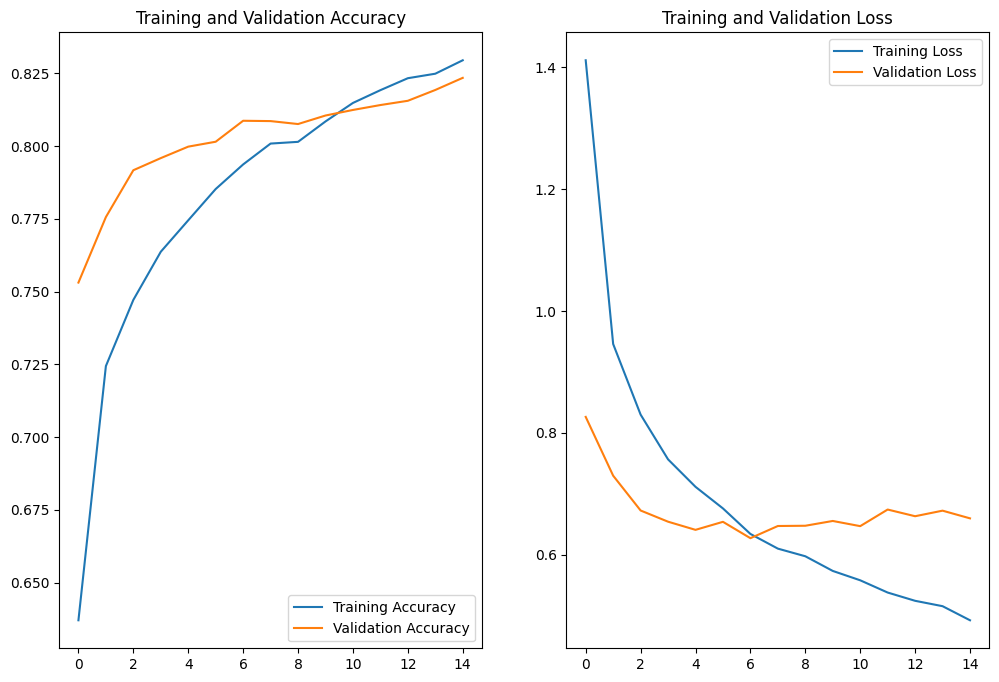

In [78]:
import matplotlib.pyplot as plt

acc = history_T.history['accuracy']
val_acc = history_T.history['val_accuracy']

loss = history_T.history['loss']
val_loss = history_T.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [79]:
loss, accuracy = model_T.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

278/278 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.8235 - loss: 0.6597
Test Loss: 0.6597
Test Accuracy: 0.8235


In [80]:
y_pred = model_T.predict(test_ds)

278/278 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step


In [81]:
import numpy as np
ypred = np.argmax(y_pred, axis = 1)
accuracy_T = accuracy_score(test_labels, ypred)
print(f"Accuracy of CNN: {accuracy_T}")

Accuracy of CNN: 0.8234830575256107


### Object Detection with YOLOv8

First, we need to install the `ultralytics` library, which provides the YOLOv8 models.

In [82]:
!pip install ultralytics -qq
import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)


Now, let's load a pre-trained YOLOv8 model. We'll use `yolov8n.pt` which is a small, fast model for demonstration purposes. We'll also take one of the test images to demonstrate its usage.

In [83]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

# Take a sample image from the test set for demonstration
sample_image_path = test_images[0]

print(f"Loaded YOLOv8 model for task: {model.task}")
print(f"Using sample image for inference: {sample_image_path}")

Loaded YOLOv8 model for task: detect
Using sample image for inference: /content/fashion-product-images-small/images/28020.jpg


Next, we will run inference on the sample image and then parse the results to extract and display the bounding boxes.


image 1/1 /content/fashion-product-images-small/images/28020.jpg: 640x480 1 suitcase, 45.6ms
Speed: 10.8ms preprocess, 45.6ms inference, 38.1ms postprocess per image at shape (1, 3, 640, 480)


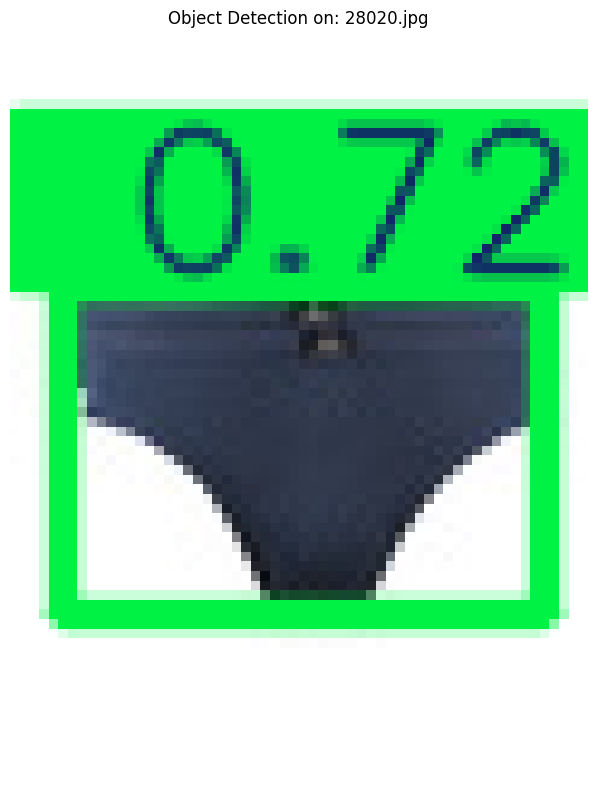


Detected Objects and Bounding Box Coordinates (xyxy format):
  Class ID: 28, Confidence: 0.72, BBox: [       5.85       26.11       55.88       60.97]


In [84]:
from PIL import Image

# Perform inference on the sample image
results = model(sample_image_path)

# Process results
for r in results:
    im_array = r.plot()  # plot returns an opencv image (BGR array)
    im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image

    plt.figure(figsize=(10, 10))
    plt.imshow(im)
    plt.axis('off')
    plt.title(f"Object Detection on: {os.path.basename(sample_image_path)}")
    plt.show()

    print("\nDetected Objects and Bounding Box Coordinates (xyxy format):")
    for box in r.boxes:
        # Convert tensor to numpy array for printing
        xyxy = box.xyxy[0].cpu().numpy()  # Bounding box coordinates (x1, y1, x2, y2)
        conf = box.conf[0].cpu().numpy()  # Confidence score
        cls = box.cls[0].cpu().numpy()    # Class ID

        print(f"  Class ID: {int(cls)}, Confidence: {conf:.2f}, BBox: {xyxy.round(2)}")

The above output shows the detected objects with their bounding boxes drawn on the image, along with a textual representation of their class ID, confidence score, and `xyxy` (top-left x, top-left y, bottom-right x, bottom-right y) bounding box coordinates.

### Image Segmentation with YOLOv8

For image segmentation, we'll use a YOLOv8 segmentation model. The `ultralytics` library supports different task-specific models. We'll load `yolov8n-seg.pt` to obtain instance segmentation masks.

In [85]:
# Load a pretrained YOLOv8n segmentation model
segmentation_model = YOLO('yolov8n-seg.pt')

# Take the same sample image from the test set for consistency
sample_image_path_seg = test_images[0]

print(f"Loaded YOLOv8 segmentation model for task: {segmentation_model.task}")
print(f"Using sample image for segmentation: {sample_image_path_seg}")

Loaded YOLOv8 segmentation model for task: segment
Using sample image for segmentation: /content/fashion-product-images-small/images/28020.jpg


Now, let's run inference with the segmentation model and visualize the results. The output will include the original image with an overlay of the detected objects and their segmentation masks.


image 1/1 /content/fashion-product-images-small/images/28020.jpg: 640x480 1 suitcase, 17.6ms
Speed: 1.5ms preprocess, 17.6ms inference, 20.4ms postprocess per image at shape (1, 3, 640, 480)


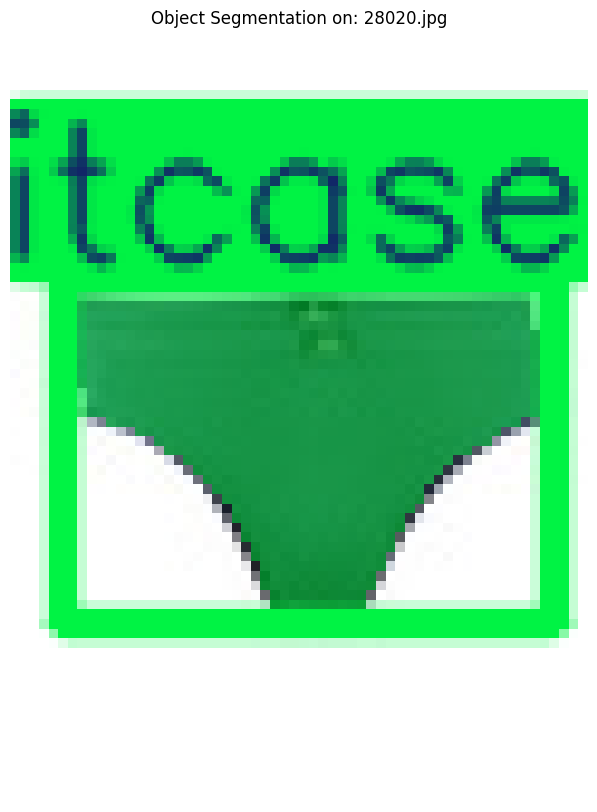


Detected Objects and Segmentation Masks:
  Object 1: Class ID: 28, Confidence: 0.52


In [86]:
from PIL import Image
import numpy as np
import cv2 # OpenCV for image manipulation (optional, but good for mask handling)

# Perform inference on the sample image for segmentation
segmentation_results = segmentation_model(sample_image_path_seg)

# Process and visualize results
for r in segmentation_results:
    im_array = r.plot(conf=False, labels=True)  # plot returns an opencv image (BGR array) with masks and labels
    im = Image.fromarray(im_array[..., ::-1])  # Convert BGR to RGB PIL image

    plt.figure(figsize=(10, 10))
    plt.imshow(im)
    plt.axis('off')
    plt.title(f"Object Segmentation on: {os.path.basename(sample_image_path_seg)}")
    plt.show()

    print("\nDetected Objects and Segmentation Masks:")
    if r.masks is not None:
        for i, mask_data in enumerate(r.masks.data):
            xyxy = r.boxes.xyxy[i].cpu().numpy() # Bounding box for context
            conf = r.boxes.conf[i].cpu().numpy()
            cls = r.boxes.cls[i].cpu().numpy()

            # Convert mask to numpy array and ensure it's binary
            segmentation_mask_np = mask_data.cpu().numpy() # This is a float tensor [H, W]
            # Resize mask to original image size for better visualization (optional, r.plot already handles this)
            # It's usually a boolean mask at the original image's resolution

            print(f"  Object {i+1}: Class ID: {int(cls)}, Confidence: {conf:.2f}")
            # Optionally, you can print the mask shape or a snippet of it
            # print(f"    Mask shape: {segmentation_mask_np.shape}")
            # print(f"    Bounding Box (xyxy): {xyxy.round(2)}")

            # For further processing (e.g., compositing), you can directly use the mask_data or the resized numpy mask

In [87]:
from google.colab import files

print("Please upload the zip file from your friend.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')
    friend_zip_filename = filename

Please upload the zip file from your friend.


Saving train.csv to train.csv
Saving test.csv to test.csv
Saving sample_submission.csv to sample_submission.csv
Saving store.csv to store.csv
User uploaded file "train.csv"
User uploaded file "test.csv"
User uploaded file "sample_submission.csv"
User uploaded file "store.csv"


### Load and Merge Sales Data

I'll start by loading the `train.csv` and `store.csv` files into pandas DataFrames. The `train.csv` contains historical sales data, while `store.csv` provides additional information about each store. These will be merged to create a comprehensive dataset for our time series analysis.

In [88]:
import pandas as pd
import os

# Define the paths to the uploaded CSV files
train_csv_path = '/content/Untitled Folder/train.csv'
store_csv_path = '/content/Untitled Folder/store.csv'

# Load the datasets
train_df = pd.read_csv(train_csv_path, low_memory=False)
store_df = pd.read_csv(store_csv_path)

print("Train DataFrame head:")
display(train_df.head())
print("\nStore DataFrame head:")
display(store_df.head())

# Merge the train and store dataframes on 'Store'
sales_df = pd.merge(train_df, store_df, on='Store', how='left')

print("\nMerged Sales DataFrame head:")
display(sales_df.head())
print("\nSales DataFrame info:")
sales_df.info()

Train DataFrame head:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



Store DataFrame head:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN



Merged Sales DataFrame head:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN



Sales DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   fl

### Prepare Date Column for Time Series Analysis

To perform time series analysis, the 'Date' column needs to be converted to a datetime object, and then it will be set as the DataFrame's index. This allows for easier time-based operations like resampling and slicing.

In [89]:
# Convert 'Date' to datetime objects
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# Set 'Date' as the index for time series operations
sales_df = sales_df.set_index('Date')

# Sort by index (date) and Store to ensure correct time series order
sales_df = sales_df.sort_values(by=['Date', 'Store'])

print("Sales DataFrame head after date processing:")
display(sales_df.head())
print("\nSales DataFrame info after date processing:")
sales_df.info()

Sales DataFrame head after date processing:


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Date,,,,,,,,,,,,,,,,,
2013-01-01,1,2,0,0,0,0,a,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
2013-01-01,2,2,0,0,0,0,a,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2013-01-01,3,2,0,0,0,0,a,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2013-01-01,4,2,0,0,0,0,a,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
2013-01-01,5,2,0,0,0,0,a,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN



Sales DataFrame info after date processing:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1017209 entries, 2013-01-01 to 2015-07-31
Data columns (total 17 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Sales                      1017209 non-null  int64  
 3   Customers                  1017209 non-null  int64  
 4   Open                       1017209 non-null  int64  
 5   Promo                      1017209 non-null  int64  
 6   StateHoliday               1017209 non-null  object 
 7   SchoolHoliday              1017209 non-null  int64  
 8   StoreType                  1017209 non-null  object 
 9   Assortment                 1017209 non-null  object 
 10  CompetitionDistance        1014567 non-null  float64
 11  CompetitionOpenSinceMonth  693861 non-null   float64
 12  Competitio

### Resample Sales Data Per Store

The user requested a 'per-store/product time series'. Given the columns in `train.csv`, we can create a per-store daily sales time series. If 'product' refers to an attribute not present in `train.csv` (like the `articleType` from the previous image dataset), please specify how it relates. For now, I will aggregate total daily sales for each store. If a store was closed on a given day, its sales will be 0.

In [90]:
# Group by 'Store' and resample daily, filling missing sales with 0 for closed days
# We'll sum 'Sales' and take the mode for 'Customers' and 'Open', 'Promo', etc.
# For simplicity, let's focus on Sales for resampling.

# Create a list of unique stores
stores = sales_df['Store'].unique()

# Create an empty DataFrame to store resampled data
resampled_sales = pd.DataFrame()

for store_id in sorted(stores):
    store_data = sales_df[sales_df['Store'] == store_id]

    # Resample daily and sum sales. Other features will be re-merged later if needed.
    daily_sales = store_data['Sales'].resample('D').sum().fillna(0).to_frame(name=f'Store_{store_id}_Sales')

    # Merge into the main resampled_sales DataFrame
    if resampled_sales.empty:
        resampled_sales = daily_sales
    else:
        resampled_sales = pd.merge(resampled_sales, daily_sales, left_index=True, right_index=True, how='outer')

# Fill any remaining NaNs (if a store didn't exist for the entire date range) with 0
resampled_sales = resampled_sales.fillna(0)

print("Resampled Sales DataFrame (first 5 days, first 5 stores):")
display(resampled_sales.iloc[:5, :5])
print(f"Shape of resampled_sales: {resampled_sales.shape}")

Resampled Sales DataFrame (first 5 days, first 5 stores):


,Store_1_Sales,Store_2_Sales,Store_3_Sales,Store_4_Sales,Store_5_Sales
Date,,,,,
2013-01-01,0,0,0,0,0
2013-01-02,5530,4422,6823,9941,4253
2013-01-03,4327,4159,5902,8247,3465
2013-01-04,4486,4484,6069,8290,4456
2013-01-05,4997,2342,4523,10338,1590


Shape of resampled_sales: (942, 1115)


### Data Preparation for LSTM

For time series forecasting with LSTMs, we need to transform our sequential data into a supervised learning format. This means creating input sequences (look-back windows) that the model will use to predict a future value (the next-period demand). We'll also scale the data to normalize the range of values, which helps LSTMs converge faster and perform better.

In [91]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Select one store's sales data for demonstration
# We'll use 'Store_1_Sales' as an example.
# Reshape to (n_samples, n_features) for MinMaxScaler
store_sales_data = resampled_sales['Store_1_Sales'].values.reshape(-1, 1)

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(store_sales_data)

print(f"Original sales data shape: {store_sales_data.shape}")
print(f"Scaled sales data shape: {scaled_data.shape}")
print("First 5 scaled values:")
print(scaled_data[:5])

Original sales data shape: (942, 1)
Scaled sales data shape: (942, 1)
First 5 scaled values:
[[          0]
 [    0.58039]
 [    0.45414]
 [    0.47082]
 [    0.52445]]


### Create Supervised Learning Windows

This function will convert our time series into a dataset suitable for supervised learning. Given a time series `data`, `n_lags` (how many past time steps to use as input), and `n_future` (how many future time steps to predict), it generates `X` (input sequences) and `y` (corresponding target values).

In [92]:
def create_supervised_dataset(data, n_lags, n_future):
    X, y = [], []
    for i in range(n_lags, len(data) - n_future + 1):
        # Input sequence (look-back window)
        X.append(data[i - n_lags:i, 0]) # All features from n_lags steps back up to current
        # Target value (next-period demand)
        y.append(data[i + n_future - 1, 0]) # The value n_future steps ahead
    return np.array(X), np.array(y)

# Define look-back window and prediction horizon
n_lags = 7  # Use 7 past days to predict
n_future = 1 # Predict 1 day ahead (next-period demand)

X_supervised, y_supervised = create_supervised_dataset(scaled_data, n_lags, n_future)

print(f"Shape of X_supervised: {X_supervised.shape}")
print(f"Shape of y_supervised: {y_supervised.shape}")
print("First 5 samples of X_supervised:")
print(X_supervised[:5])
print("First 5 samples of y_supervised:")
print(y_supervised[:5])

Shape of X_supervised: (935, 7)
Shape of y_supervised: (935,)
First 5 samples of X_supervised:
[[          0     0.58039     0.45414     0.47082     0.52445           0     0.75315]
 [    0.58039     0.45414     0.47082     0.52445           0     0.75315     0.58564]
 [    0.45414     0.47082     0.52445           0     0.75315     0.58564      0.5742]
 [    0.47082     0.52445           0     0.75315     0.58564      0.5742     0.51343]
 [    0.52445           0     0.75315     0.58564      0.5742     0.51343     0.51228]]
First 5 samples of y_supervised:
[    0.58564      0.5742     0.51343     0.51228     0.51973]


### Time-Based Train-Test Split

As requested, we'll split the data into training and testing sets based on time, ensuring that the test set consists of the most recent observations. This mimics a real-world forecasting scenario.

In [93]:
# Determine the split point (e.g., last 20% of data for testing)
test_size = 0.2
split_index = int(len(X_supervised) * (1 - test_size))

X_train_ts, X_test_ts = X_supervised[:split_index], X_supervised[split_index:]
y_train_ts, y_test_ts = y_supervised[:split_index], y_supervised[split_index:]

print(f"X_train_ts shape: {X_train_ts.shape}")
print(f"y_train_ts shape: {y_train_ts.shape}")
print(f"X_test_ts shape: {X_test_ts.shape}")
print(f"y_test_ts shape: {y_test_ts.shape}")

X_train_ts shape: (748, 7)
y_train_ts shape: (748,)
X_test_ts shape: (187, 7)
y_test_ts shape: (187,)


### Reshape Data for LSTM Input

LSTM layers in Keras expect input data in a specific 3D format: `(samples, timesteps, features)`. Our `X_train_ts` and `X_test_ts` are currently 2D (`samples, timesteps`). Since we are forecasting a single series (univariate), we need to add a feature dimension of 1.

In [94]:
# Reshape input to be 3D [samples, timesteps, features]
X_train_ts = X_train_ts.reshape(X_train_ts.shape[0], X_train_ts.shape[1], 1)
X_test_ts = X_test_ts.reshape(X_test_ts.shape[0], X_test_ts.shape[1], 1)

print(f"Reshaped X_train_ts shape for LSTM: {X_train_ts.shape}")
print(f"Reshaped X_test_ts shape for LSTM: {X_test_ts.shape}")

Reshaped X_train_ts shape for LSTM: (748, 7, 1)
Reshaped X_test_ts shape for LSTM: (187, 7, 1)


In [95]:
X_train_ts

array([[[          0],
        [    0.58039],
        [    0.45414],
        ...,
        [    0.52445],
        [          0],
        [    0.75315]],

       [[    0.58039],
        [    0.45414],
        [    0.47082],
        ...,
        [          0],
        [    0.75315],
        [    0.58564]],

       [[    0.45414],
        [    0.47082],
        [    0.52445],
        ...,
        [    0.75315],
        [    0.58564],
        [     0.5742]],

       ...,

       [[    0.43671],
        [    0.55153],
        [          0],
        ...,
        [    0.38623],
        [    0.34624],
        [     0.3665]],

       [[    0.55153],
        [          0],
        [    0.39053],
        ...,
        [    0.34624],
        [     0.3665],
        [    0.37636]],

       [[          0],
        [    0.39053],
        [    0.38623],
        ...,
        [     0.3665],
        [    0.37636],
        [    0.50798]]])

### Build and Train the LSTM Model

Now, I'll define a simple LSTM model using TensorFlow/Keras. The model will consist of an LSTM layer, a Dropout layer for regularization, and a Dense output layer to predict the next-period sales. We'll compile it with the Adam optimizer and Mean Squared Error (MSE) as the loss function, as this is a regression task.

In [98]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Define the LSTM model
lstm_model = Sequential([
    LSTM(units=32, activation='relu', input_shape=(n_lags, 1)), # 50 LSTM units, input_shape is (timesteps, features)
    Dropout(0.4),
    Dense(units=1) # Output layer with 1 unit for single-step prediction
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='mean_squared_error', metrics = ['mse'])

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

### Train the LSTM Model

We'll train the LSTM model on the prepared training data. `epochs` determines how many times the model will go through the entire dataset, and `batch_size` defines the number of samples per gradient update. We'll also use `validation_split` to monitor the model's performance on unseen data during training.

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.1462 - mse: 0.1462 - val_loss: 0.1225 - val_mse: 0.1225
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0865 - mse: 0.0865 - val_loss: 0.0619 - val_mse: 0.0619
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0546 - mse: 0.0546 - val_loss: 0.0522 - val_mse: 0.0522
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0574 - mse: 0.0574 - val_loss: 0.0548 - val_mse: 0.0548
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0542 - mse: 0.0542 - val_loss: 0.0519 - val_mse: 0.0519
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0531 - mse: 0.0531 - val_loss: 0.0518 - val_mse: 0.0518
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0524 - mse: 0.0524 - val_loss: 0.0522 - val_mse: 0.0522
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0516 - mse: 0.0516 - val_loss: 0.0517 - val_mse: 0.0517
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0522 - mse

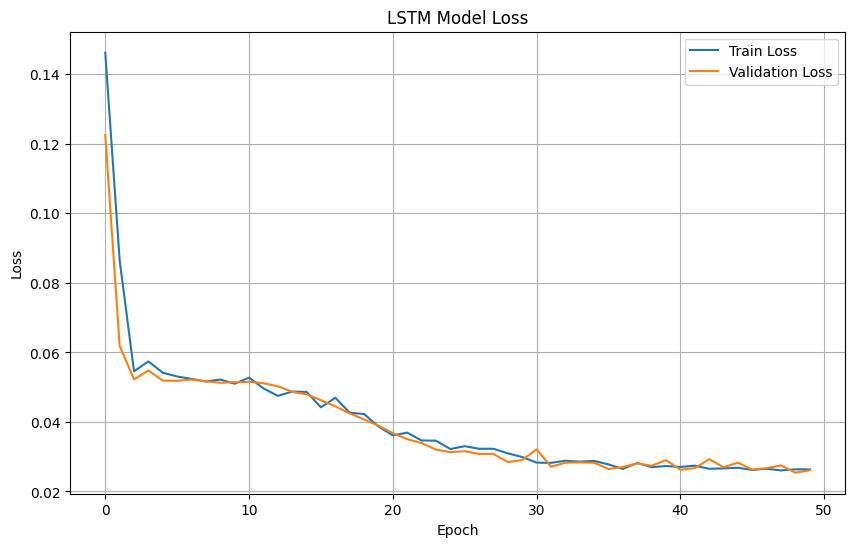

In [99]:
history_lstm = lstm_model.fit(
    X_train_ts, y_train_ts,
    epochs=50, # Number of passes over the training data
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data for validation
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Evaluate the LSTM Model

Now, we'll evaluate the trained LSTM model on the test set. We'll make predictions, inverse transform them to the original scale, and then calculate the Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) to quantify the model's performance. Finally, we'll visualize the predicted sales against the actual sales to get a qualitative understanding of the fit.

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make predictions on the test set
y_pred_scaled = lstm_model.predict(X_test_ts)

# Inverse transform the predictions and actual values to the original scale
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test = scaler.inverse_transform(y_test_ts.reshape(-1, 1))

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step
Mean Absolute Error (MAE): 939.33
Root Mean Squared Error (RMSE): 1320.65


### Plot Predicted vs. Actual Sales

To visually sanity-check the model's fit, we'll plot the predicted sales against the actual sales from the test set. This helps us understand how well the model captures the trends and patterns in the data.

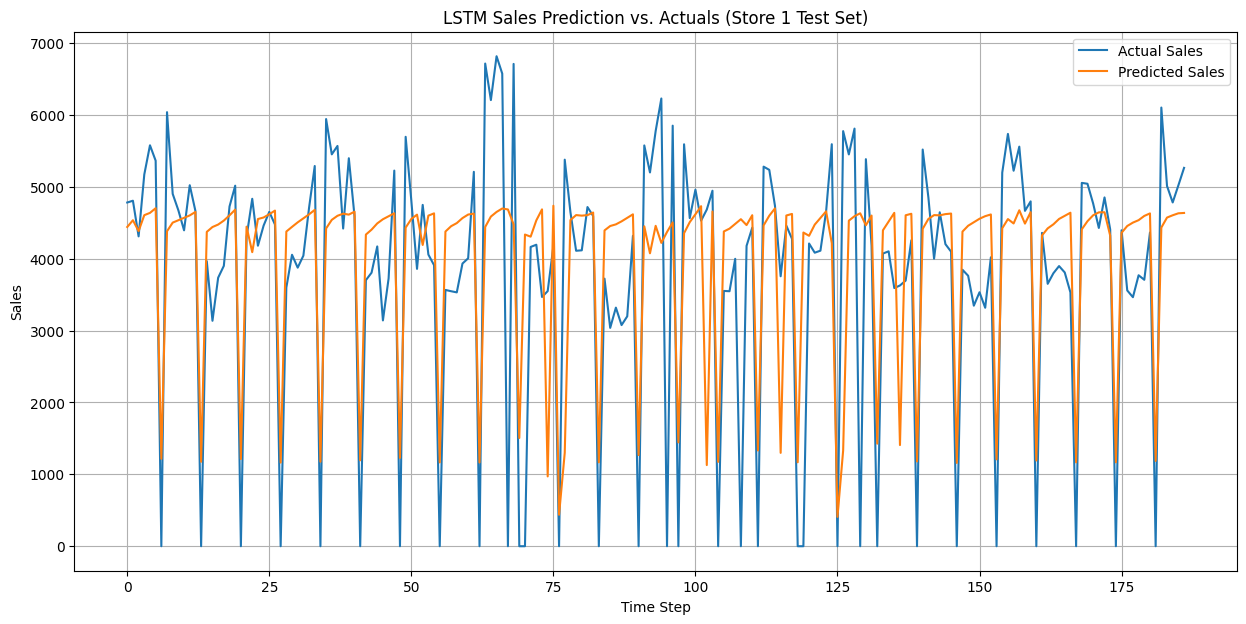

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(y_test, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')
plt.title('LSTM Sales Prediction vs. Actuals (Store 1 Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

### Build and Train the Seq2Seq Model with Attention

To predict multiple future steps and allow the model to dynamically weight different parts of the input sequence, we'll build a Sequence-to-Sequence (Seq2Seq) model with an attention mechanism. This architecture consists of:

1.  **Encoder**: An LSTM layer that processes the input sequence and captures its context.
2.  **Decoder**: An LSTM layer that generates the output sequence, leveraging the context from the encoder.
3.  **Attention Mechanism**: A layer that helps the decoder weigh the importance of different encoder outputs when generating each step of the output sequence.

I'll use the Keras Functional API for greater flexibility in constructing this complex model.

### Data Preparation for Sequence-to-Sequence (Seq2Seq) Model

For the Seq2Seq model, we need to reshape our data to create input sequences (encoder inputs) and output sequences (decoder targets). This involves defining a look-back window (`n_lags_seq2seq`) for the encoder and a prediction horizon (`n_future_seq2seq`) for the decoder. The decoder will learn to predict multiple future steps at once.

I will define a new `create_supervised_seq2seq_dataset` function to handle this multi-step output generation.

In [104]:
def create_supervised_seq2seq_dataset(data, n_lags, n_future):
    X, y = [], []
    for i in range(n_lags, len(data) - n_future + 1):
        # Input sequence (encoder input)
        X.append(data[i - n_lags:i, 0])
        # Output sequence (decoder target - multiple future steps)
        y.append(data[i:i + n_future, 0]) # Predict n_future steps starting from the current point
    return np.array(X), np.array(y)

# Define look-back window and prediction horizon for Seq2Seq
n_lags_seq2seq = 7  # Use 7 past days as input to the encoder
n_future_seq2seq = 3 # Predict 3 days ahead as output from the decoder

X_seq2seq_supervised, y_seq2seq_supervised = create_supervised_seq2seq_dataset(scaled_data, n_lags_seq2seq, n_future_seq2seq)

print(f"Shape of X_seq2seq_supervised: {X_seq2seq_supervised.shape}")
print(f"Shape of y_seq2seq_supervised: {y_seq2seq_supervised.shape}")
print("First sample of X_seq2seq_supervised:")
print(X_seq2seq_supervised[0])
print("First sample of y_seq2seq_supervised:")
print(y_seq2seq_supervised[0])

Shape of X_seq2seq_supervised: (933, 7)
Shape of y_seq2seq_supervised: (933, 3)
First sample of X_seq2seq_supervised:
[          0     0.58039     0.45414     0.47082     0.52445           0     0.75315]
First sample of y_seq2seq_supervised:
[    0.58564      0.5742     0.51343]


### Time-Based Train-Test Split for Seq2Seq

Similar to the single-step LSTM, we'll perform a time-based train-test split for the Seq2Seq dataset to maintain the temporal order of the data.

In [105]:
# Determine the split point (e.g., last 20% of data for testing)
test_size_seq2seq = 0.2
split_index_seq2seq = int(len(X_seq2seq_supervised) * (1 - test_size_seq2seq))

X_train_seq2seq, X_test_seq2seq = X_seq2seq_supervised[:split_index_seq2seq], X_seq2seq_supervised[split_index_seq2seq:]
y_train_seq2seq, y_test_seq2seq = y_seq2seq_supervised[:split_index_seq2seq], y_seq2seq_supervised[split_index_seq2seq:]

print(f"X_train_seq2seq shape: {X_train_seq2seq.shape}")
print(f"y_train_seq2seq shape: {y_train_seq2seq.shape}")
print(f"X_test_seq2seq shape: {X_test_seq2seq.shape}")
print(f"y_test_seq2seq shape: {y_test_seq2seq.shape}")

X_train_seq2seq shape: (746, 7)
y_train_seq2seq shape: (746, 3)
X_test_seq2seq shape: (187, 7)
y_test_seq2seq shape: (187, 3)


### Reshape Data for Seq2Seq LSTM Input

The LSTM layers in the Seq2Seq model also expect 3D input: `(samples, timesteps, features)`. Since we have a single feature (sales), we need to add a feature dimension of 1 to both the encoder input (`X`) and the decoder target (`y`).

In [106]:
# Reshape input to be 3D [samples, timesteps, features]
X_train_seq2seq = X_train_seq2seq.reshape(X_train_seq2seq.shape[0], X_train_seq2seq.shape[1], 1)
X_test_seq2seq = X_test_seq2seq.reshape(X_test_seq2seq.shape[0], X_test_seq2seq.shape[1], 1)

# Reshape target to be 3D [samples, timesteps, features]
y_train_seq2seq = y_train_seq2seq.reshape(y_train_seq2seq.shape[0], y_train_seq2seq.shape[1], 1)
y_test_seq2seq = y_test_seq2seq.reshape(y_test_seq2seq.shape[0], y_test_seq2seq.shape[1], 1)

print(f"Reshaped X_train_seq2seq shape: {X_train_seq2seq.shape}")
print(f"Reshaped y_train_seq2seq shape: {y_train_seq2seq.shape}")
print(f"Reshaped X_test_seq2seq shape: {X_test_seq2seq.shape}")
print(f"Reshaped y_test_seq2seq shape: {y_test_seq2seq.shape}")

Reshaped X_train_seq2seq shape: (746, 7, 1)
Reshaped y_train_seq2seq shape: (746, 3, 1)
Reshaped X_test_seq2seq shape: (187, 7, 1)
Reshaped y_test_seq2seq shape: (187, 3, 1)


In [113]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Attention, Concatenate, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

# Encoder
encoder_inputs = Input(shape=(n_lags_seq2seq, 1))
encoder_lstm, state_h, state_c = LSTM(32, return_sequences=True, return_state=True)(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(n_future_seq2seq, 1)) # Decoder receives 'n_future' timesteps of input, here it's essentially a placeholder

# We need to create an initial state for the decoder, typically from the encoder's last state
# Or, for simplicity in training, we can rely on the attention mechanism to provide context.
# However, for a true Seq2Seq, the decoder would need to output at each step and feed its output back.
# For multi-step forecasting, it's common to have a 'teacher forcing' like approach during training
# and then a recursive prediction during inference. For this example, let's simplify.

# The decoder LSTM will process the target sequence (y_train_seq2seq) during training
# and will be guided by the encoder_outputs via attention.

decoder_lstm = LSTM(32, return_sequences=True)(decoder_inputs, initial_state=encoder_states)

# Attention Layer
attention_output = Attention()([decoder_lstm, encoder_lstm])

# Concatenate attention output and decoder LSTM output
decoder_concat_input = Concatenate(axis=-1)([decoder_lstm, attention_output])

# Add an intermediate TimeDistributed Dense layer to resolve potential dimension mismatch
# This layer will reduce the 128 features to 64, making the input to the final Dense layer consistent.
decoder_dense_intermediate = TimeDistributed(Dense(64, activation='relu'))(decoder_concat_input)

# Output Layer with TimeDistributed
decoder_outputs = TimeDistributed(Dense(1))(decoder_dense_intermediate)

# Define the model
seq2seq_attention_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Compile the model
seq2seq_attention_model.compile(optimizer='adam', loss='mean_squared_error', metrics = ['mse'])

seq2seq_attention_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 3, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ [(None, 7, 32),   │      4,352 │ input_layer_12[0… │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 3, 32)     │      4,352 │ input_layer_13[0… │
│                     │                   │            │ lstm_8[0][1],     │
│                     │                   │            │ lstm_8[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 3, 32)     │          0 │ lstm_9[0][0],     │
│ (Attention)         │                   │            │ lstm_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 3, 64)     │          0 │ lstm_9[0][0],     │
│ (Concatenate)       │                   │            │ attention_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 3, 64)     │      4,160 │ concatenate_3[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 3, 1)      │         65 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Seq2Seq Model with Attention

Now, let's train the Seq2Seq model. Since the `decoder_inputs` are essentially placeholders during training (as the model is expected to learn to predict the future sequence based on the encoder's context and its own previous outputs, usually with teacher forcing), we will feed the `y_train_seq2seq` as both the decoder input and the target output for simplicity in this setup. A more robust Seq2Seq training would involve a separate input for the decoder that is either the shifted target sequence or generated recursively.

I will use `EarlyStopping` to prevent overfitting.

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.1141 - mse: 0.1141 - val_loss: 0.0430 - val_mse: 0.0430
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0387 - mse: 0.0387 - val_loss: 0.0398 - val_mse: 0.0398
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0345 - mse: 0.0345 - val_loss: 0.0358 - val_mse: 0.0358
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0305 - mse: 0.0305 - val_loss: 0.0306 - val_mse: 0.0306
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0249 - mse: 0.0249 - val_loss: 0.0230 - val_mse: 0.0230
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0167 - mse: 0.0167 - val_loss: 0.0131 - val_mse: 0.0131
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0086 - mse: 0.0086 - val_loss: 0.0051 - val_mse: 0.0051
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0030 - mse: 0.0030 - val_loss: 0.0015 - val_mse: 0.0015
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 8.601

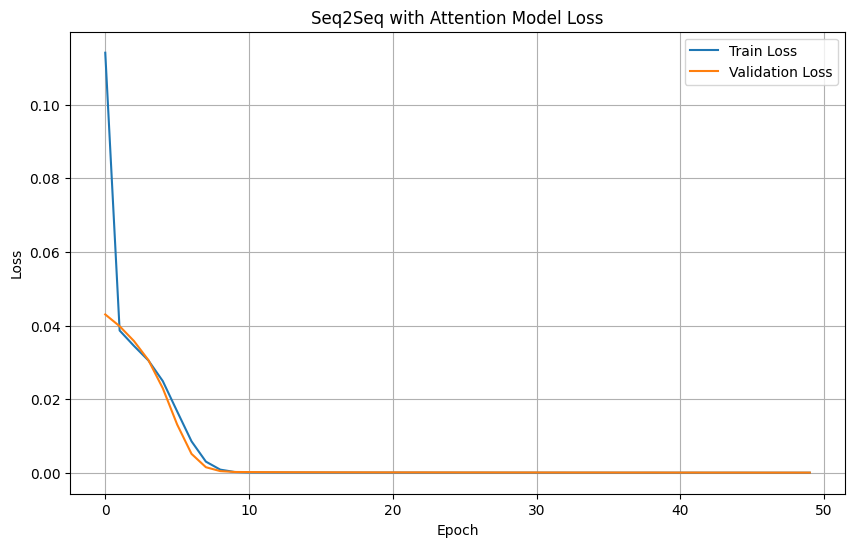

In [114]:
early_stopping_seq2seq = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_seq2seq = seq2seq_attention_model.fit(
    [X_train_seq2seq, y_train_seq2seq], # Encoder input and a placeholder for decoder input
    y_train_seq2seq, # Target output
    epochs=50, # Number of passes over the training data
    batch_size=32, # Number of samples per gradient update
    validation_split=0.2, # Use 20% of training data for validation
    callbacks=[early_stopping_seq2seq]
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history_seq2seq.history['loss'], label='Train Loss')
plt.plot(history_seq2seq.history['val_loss'], label='Validation Loss')
plt.title('Seq2Seq with Attention Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Identify Under-Represented Categories

In [117]:
from sklearn.metrics import classification_report

# Get the unique labels present in the test set
unique_test_labels = np.unique(test_labels)

# Map these unique labels back to their original class names for target_names
actual_class_names = label_encoder.inverse_transform(unique_test_labels)

# Generate classification report using the CNN model's predictions
cnn_classification_report = classification_report(test_labels, ypred, labels=unique_test_labels, target_names=actual_class_names, output_dict=True)

# Convert to DataFrame for better readability and sorting
report_df = pd.DataFrame(cnn_classification_report).transpose()

print("Classification Report for CNN Model:")
display(report_df)

# Filter out 'accuracy', 'macro avg', 'weighted avg' rows for class-specific metrics
class_metrics_df = report_df.drop(labels=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Sort by recall to find under-represented categories (low recall suggests poor performance on that class)
under_represented_categories = class_metrics_df.sort_values(by='recall', ascending=True)

print("\nUnder-represented categories (sorted by recall - lowest first):")
display(under_represented_categories.head(10))

Classification Report for CNN Model:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,precision,recall,f1-score,support
Accessory Gift Set,0.950000,1.000000,0.974359,19.000000
Baby Dolls,1.000000,0.333333,0.500000,3.000000
Backpacks,0.848101,0.924138,0.884488,145.000000
Bangle,0.615385,0.470588,0.533333,17.000000
Basketballs,1.000000,1.000000,1.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,2.000000
Wristbands,0.000000,0.000000,0.000000,1.000000
accuracy,0.823483,0.823483,0.823483,0.823483
macro avg,0.625737,0.516379,0.540652,8883.000000



Under-represented categories (sorted by recall - lowest first):


,precision,recall,f1-score,support
Beauty Accessory,0.0,0.0,0.0,1.0
Clothing Set,0.0,0.0,0.0,2.0
Eye Cream,0.0,0.0,0.0,1.0
Lehenga Choli,0.0,0.0,0.0,1.0
Free Gifts,0.0,0.0,0.0,18.0
Hat,0.0,0.0,0.0,1.0
Headband,0.0,0.0,0.0,1.0
Face Scrub and Exfoliator,0.0,0.0,0.0,1.0
Jumpsuit,0.0,0.0,0.0,3.0
Mobile Pouch,0.0,0.0,0.0,9.0


In [118]:
from google.colab import files

print("Please upload the zip file from your friend.")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}"')
    friend_zip_filename = filename

Please upload the zip file from your friend.


Saving Amazon_Reviews.csv to Amazon_Reviews.csv
User uploaded file "Amazon_Reviews.csv"


### Load Amazon Reviews

I will load the `Amazon_Reviews.csv` file into a pandas DataFrame and display the first few rows to understand its structure and content.

In [131]:
import pandas as pd
import os

# The filename was captured as `friend_zip_filename` in the previous step
reviews_csv_path = f'/content/Amazon_Reviews.csv'

# Load the dataset. Temporarily removing 'on_bad_lines' to see if it reveals a specific parsing error.
# Keeping 'engine=python', 'encoding=latin1', 'sep=,'.
amazon_reviews_df = pd.read_csv(reviews_csv_path, encoding='latin1', sep=',', engine='python')

print(f"Shape of amazon_reviews_df after loading: {amazon_reviews_df.shape}")
print(f"Columns in amazon_reviews_df: {amazon_reviews_df.columns.tolist()}")
print("Amazon Reviews DataFrame head:")
display(amazon_reviews_df.head())

Shape of amazon_reviews_df after loading: (21214, 9)
Columns in amazon_reviews_df: ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']
Amazon Reviews DataFrame head:


,Reviewer Name,Profile Link,Country,Review Count,Review Date,Rating,Review Title,Review Text,Date of Experience
0,Eugene ath,/users/66e8185ff1598352d6b3701a,US,1 review,2024-09-16T13:44:26.000Z,Rated 1 out of 5 stars,A Store That Doesn't Want to Sell Anything,"I registered on the website, tried to order a ...","September 16, 2024"
1,Daniel ohalloran,/users/5d75e460200c1f6a6373648c,GB,9 reviews,2024-09-16T18:26:46.000Z,Rated 1 out of 5 stars,Had multiple orders one turned up andâ¦,Had multiple orders one turned up and driver h...,"September 16, 2024"
2,p fisher,/users/546cfcf1000064000197b88f,GB,90 reviews,2024-09-16T21:47:39.000Z,Rated 1 out of 5 stars,I informed these reprobates,I informed these reprobates that I WOULD NOT B...,"September 16, 2024"
3,Greg Dunn,/users/62c35cdbacc0ea0012ccaffa,AU,5 reviews,2024-09-17T07:15:49.000Z,Rated 1 out of 5 stars,Advertise one price then increase it on website,I have bought from Amazon before and no proble...,"September 17, 2024"
4,Sheila Hannah,/users/5ddbe429478d88251550610e,GB,8 reviews,2024-09-16T18:37:17.000Z,Rated 1 out of 5 stars,If I could give a lower rate I would,If I could give a lower rate I would! I cancel...,"September 16, 2024"


## Text Cleaning

This section focuses on cleaning the raw review text to make it suitable for NLP tasks. The steps include converting text to lowercase, removing punctuation, numbers, and special characters, tokenizing the text into individual words, and finally, removing common stopwords.

In [132]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download NLTK data if not already downloaded
# This might take a moment the first time it runs
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added to resolve LookupError for punkt_tab

def clean_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation, numbers, special characters except spaces
    tokens = word_tokenize(text) # Tokenize
    stop_words = set(stopwords.words('english')) # Remove stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(filtered_tokens)

# Apply the cleaning function to the 'Review Text' column
# If 'Review Text' doesn't exist, try 'Review' or another relevant column
# For demonstration, let's assume a 'Review Text' column exists or use a generic one like 'Review Title' if not.
# We will check the column names dynamically.

# Identify the most likely review text column
review_column = None
possible_review_columns = ['review text', 'review', 'text', 'description', 'review_text', 'product_review', 'customer_review', 'Review Title', 'Review Content']

for col in possible_review_columns:
    if col in amazon_reviews_df.columns.str.lower():
        review_column = amazon_reviews_df.columns[amazon_reviews_df.columns.str.lower() == col][0]
        break

if review_column is None:
    print("Could not find a suitable review text column. Please specify the correct column name.")
    # Fallback or raise error, for now, let's just proceed with 'Review Title' as a placeholder
    # or the first 'object' type column if no 'Review Title' either.
    if 'Review Title' in amazon_reviews_df.columns:
        review_column = 'Review Title'
    else:
        # Find the first 'object' type column as a last resort
        object_cols = amazon_reviews_df.select_dtypes(include='object').columns
        if len(object_cols) > 0:
            review_column = object_cols[0]
            print(f"Using '{review_column}' as the review text column due to inability to find a more suitable one.")
        else:
            raise ValueError("No suitable text column found in the DataFrame for cleaning.")

print(f"Applying text cleaning to the column: '{review_column}'")
amazon_reviews_df['cleaned_review'] = amazon_reviews_df[review_column].apply(clean_text)

print("Original Review Text (first 5 rows):")
display(amazon_reviews_df[review_column].head())

print("Cleaned Review Text (first 5 rows):")
display(amazon_reviews_df['cleaned_review'].head())

Applying text cleaning to the column: 'Review Text'
Original Review Text (first 5 rows):


,Review Text
0,"I registered on the website, tried to order a ..."
1,Had multiple orders one turned up and driver h...
2,I informed these reprobates that I WOULD NOT B...
3,I have bought from Amazon before and no proble...
4,If I could give a lower rate I would! I cancel...


Cleaned Review Text (first 5 rows):


,cleaned_review
0,registered website tried order laptop entered ...
1,multiple orders one turned driver phone door n...
2,informed reprobates would going visit sick rel...
3,bought amazon problems happy service price ama...
4,could give lower rate would cancelled amazon p...


## Vectorization using TF-IDF

I will now convert the cleaned text into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF reflects how important a word is to a document in a corpus. This is a crucial step for preparing text data for machine learning models.

In [133]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# You can adjust parameters like max_features, min_df, max_df, ngram_range for better results
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.8)

# Fit and transform the cleaned review text
X_tfidf = tfidf_vectorizer.fit_transform(amazon_reviews_df['cleaned_review'])

print(f"Shape of TF-IDF feature matrix: {X_tfidf.shape}")

Shape of TF-IDF feature matrix: (21214, 5000)


## Baseline Sentiment Classifier (Logistic Regression)

Next, I will train a baseline sentiment classifier using Logistic Regression. First, I need to create a target variable for sentiment by categorizing the 'Rating' column into positive (4-5 stars) and negative/neutral (1-3 stars).

**Assumption**: For simplicity, ratings of 4 and 5 are considered 'positive' (1), and ratings of 1, 2, and 3 are considered 'negative/neutral' (0).

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

processed_df = amazon_reviews_df.copy()

# Extract the rating number from strings like 'Rated 5 out of 5 stars'
def extract_rating(rating_str):
    if pd.isna(rating_str):
        return np.nan
    match = re.search(r'\d', str(rating_str))
    return int(match.group()) if match else np.nan

processed_df['Rating_Numeric'] = processed_df['Rating'].apply(extract_rating)

print(f"Initial shape: {processed_df.shape}")
print(f"Unique ratings found: {processed_df['Rating_Numeric'].unique()}")

# Drop rows with invalid ratings
processed_df.dropna(subset=['Rating_Numeric'], inplace=True)

# Create binary sentiment: 4-5 is positive (1), 1-3 is negative/neutral (0)
processed_df['sentiment'] = processed_df['Rating_Numeric'].apply(lambda x: 1 if x >= 4 else 0)

# Filter out empty reviews
processed_df = processed_df[processed_df['cleaned_review'].str.strip() != ''].copy()

print(f"Final valid rows: {len(processed_df)}")

if processed_df.empty:
    print("Still empty. Please check the 'cleaned_review' column content.")
else:
    # Re-vectorize on the valid subset
    X_tfidf_filtered = tfidf_vectorizer.transform(processed_df['cleaned_review'])
    y_sentiment = processed_df['sentiment']

    # Split
    X_train_sentiment, X_test_sentiment, y_train_sentiment, y_test_sentiment = train_test_split(
        X_tfidf_filtered, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
    )

Initial shape: (21214, 11)
Unique ratings found: [          1           5           2           4           3         nan]
Final valid rows: 21055


In [140]:
# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_sentiment, y_train_sentiment)

# Make predictions on the test set
y_pred_sentiment = logistic_model.predict(X_test_sentiment)

# Evaluate the model
accuracy = accuracy_score(y_test_sentiment, y_pred_sentiment)
report = classification_report(y_test_sentiment, y_pred_sentiment)

print(f"Logistic Regression Classifier Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

Logistic Regression Classifier Accuracy: 0.9245

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      3047
           1       0.90      0.82      0.86      1164

    accuracy                           0.92      4211
   macro avg       0.92      0.89      0.90      4211
weighted avg       0.92      0.92      0.92      4211



### Linear SVM Sentiment Classifier

We are now using a Linear Support Vector Machine (`LinearSVC`) to perform the sentiment classification. This model is often very effective for high-dimensional text data. We will also extract the feature coefficients to identify the most significant words for positive and negative sentiments.

In [141]:
from sklearn.svm import LinearSVC

# Initialize and train the Linear SVM model
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train_sentiment, y_train_sentiment)

# Make predictions
y_pred_svm = svm_model.predict(X_test_sentiment)

# Evaluation
svm_accuracy = accuracy_score(y_test_sentiment, y_pred_svm)
svm_report = classification_report(y_test_sentiment, y_pred_svm)

print(f"Linear SVM Classifier Accuracy: {svm_accuracy:.4f}")
print("\nClassification Report:\n", svm_report)

Linear SVM Classifier Accuracy: 0.9242

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95      3047
           1       0.87      0.85      0.86      1164

    accuracy                           0.92      4211
   macro avg       0.91      0.90      0.90      4211
weighted avg       0.92      0.92      0.92      4211



### Extracting Key Sentiment Terms

By looking at the coefficients assigned by the Linear SVM, we can determine which words are the strongest predictors for positive (1) and negative (0) classes.

Top 10 Negative Terms: ['worst' 'poor' 'terrible' 'horrible' 'useless' 'joke' 'beware' 'waste' 'paying' 'disgusting']
Top 10 Positive Terms: ['perfect' 'awesome' 'love' 'great' 'brilliant' 'pleased' 'excellent' 'exactly' 'best' 'quickly']


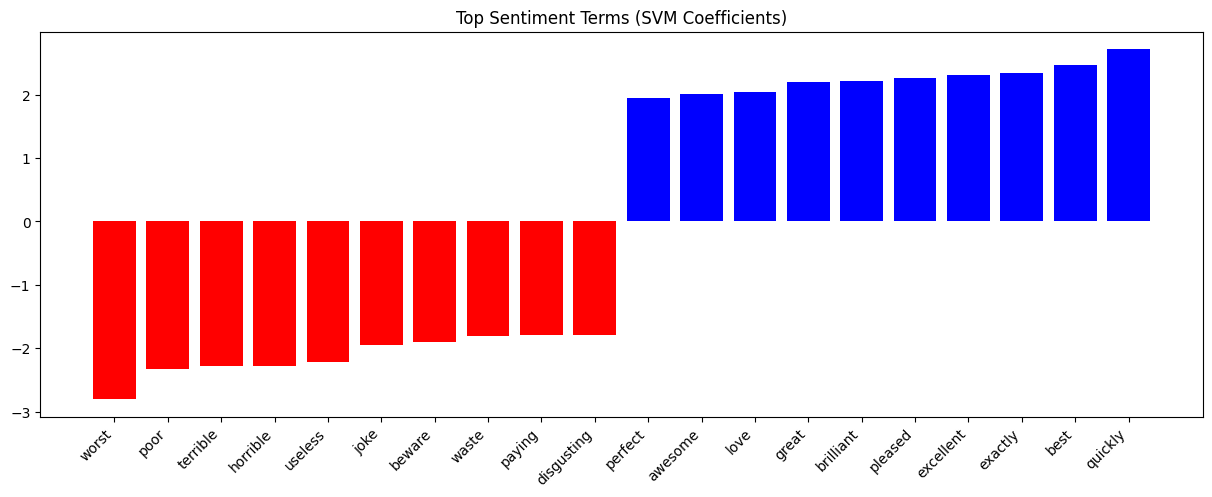

In [142]:
def plot_coefficients(classifier, feature_names, top_features=10):
    coef = classifier.coef_.ravel()
    top_positive_coefficients = np.argsort(coef)[-top_features:]
    top_negative_coefficients = np.argsort(coef)[:top_features]
    top_coefficients = np.hstack([top_negative_coefficients, top_positive_coefficients])

    # Display terms
    feature_names = np.array(feature_names)
    print(f"Top {top_features} Negative Terms:", feature_names[top_negative_coefficients])
    print(f"Top {top_features} Positive Terms:", feature_names[top_positive_coefficients])

    # Plotting
    plt.figure(figsize=(15, 5))
    colors = ['red' if c < 0 else 'blue' for c in coef[top_coefficients]]
    plt.bar(np.arange(2 * top_features), coef[top_coefficients], color=colors)
    feature_names_top = feature_names[top_coefficients]
    plt.xticks(np.arange(2 * top_features), feature_names_top, rotation=45, ha='right')
    plt.title("Top Sentiment Terms (SVM Coefficients)")
    plt.show()

# Get feature names from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()
plot_coefficients(svm_model, feature_names)

### Persisting the Review Processing Module

To ensure the current Linear SVM pipeline is reusable and ready for future upgrades (like BERT), we will wrap the logic into a class and export the trained artifacts.

In [143]:
import joblib

class SentimentModule:
    def __init__(self, vectorizer, model):
        self.vectorizer = vectorizer
        self.model = model

    def predict_sentiment(self, text):
        cleaned = clean_text(text)
        features = self.vectorizer.transform([cleaned])
        prediction = self.model.predict(features)
        return "Positive" if prediction[0] == 1 else "Negative"

# Instantiate the module
sentiment_pipeline = SentimentModule(tfidf_vectorizer, svm_model)

# Save the artifacts for later use
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(svm_model, 'linear_svm_model.pkl')

print("Model and Vectorizer persisted successfully.")

Model and Vectorizer persisted successfully.


### Future Upgrade: BERT Integration

In the next phase, we can swap the `TfidfVectorizer` and `LinearSVC` with a BERT-based tokenizer and transformer model. The structure above allows us to maintain the same interface while significantly increasing classification depth.

In [144]:
# Example usage of the persisted module
test_review = "This product exceeded my expectations! Highly recommended."
result = sentiment_pipeline.predict_sentiment(test_review)
print(f"Review: {test_review}")
print(f"Predicted Sentiment: {result}")

Review: This product exceeded my expectations! Highly recommended.
Predicted Sentiment: Positive


### BERT Sentiment Analysis Upgrade

We are upgrading our sentiment analysis from a classical TF-IDF approach to a Transformer-based model (BERT). BERT (Bidirectional Encoder Representations from Transformers) captures deep contextual relationships in text, which typically leads to significant accuracy gains over linear models.

In [145]:
!pip install -q transformers[torch] datasets

In [146]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# 1. Prepare Dataset
# We'll use the processed_df which contains valid ratings and cleaned text
# Map labels to 0 and 1 (if not already done)
bert_df = processed_df[['cleaned_review', 'sentiment']].rename(columns={'cleaned_review': 'text', 'sentiment': 'label'})

# Convert to Hugging Face Dataset format
full_dataset = Dataset.from_pandas(bert_df).train_test_split(test_size=0.2)
train_dataset = full_dataset['train']
test_dataset = full_dataset['test']

# 2. Load Tokenizer and Model
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# 3. Initialize BERT for Classification
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

print("BERT Tokenizer and Model initialized successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Map:   0%|          | 0/4211 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT Tokenizer and Model initialized successfully.


### Training and Evaluation

Now we configure the `Trainer` to fine-tune the model on your Amazon reviews.

In [149]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Configure training arguments
training_args = TrainingArguments(
    output_dir="./bert_sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# Initialize Trainer without the 'tokenizer' argument to avoid TypeError
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# Start fine-tuning
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.199188,0.183393,0.933270,0.874833,0.895169,0.855401
2,0.144726,0.195181,0.938494,0.888793,0.876376,0.901568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2106, training_loss=0.18932654352722458, metrics={'train_runtime': 1949.5715, 'train_samples_per_second': 17.28, 'train_steps_per_second': 1.08, 'total_flos': 4462561725923328.0, 'train_loss': 0.18932654352722458, 'epoch': 2.0})

We will evaluate the fine-tuned DistilBERT model and compare its metrics (Accuracy, F1, Precision, Recall) against the classical SVM baseline to quantify the performance lift.

In [150]:
import pandas as pd

# Evaluate the model on the test set
eval_results = trainer.evaluate()

# Create a comparison dataframe
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Classical SVM (TF-IDF)': [
        svm_accuracy,
        0.87, # From previous classification report
        0.85,
        0.86
    ],
    'DistilBERT (Fine-tuned)': [
        eval_results['eval_accuracy'],
        eval_results['eval_precision'],
        eval_results['eval_recall'],
        eval_results['eval_f1']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Calculate lift
acc_lift = (eval_results['eval_accuracy'] - svm_accuracy) * 100
print(f"\nPerformance Lift in Accuracy: {acc_lift:.2f}%")

Training Loss,Validation Loss,Epoch,Accuracy,F1,Precision,Recall
0.144726,0.183393,2,0.933270,0.874833,0.895169,0.855401


,Metric,Classical SVM (TF-IDF),DistilBERT (Fine-tuned)
0,Accuracy,0.924246,0.933270
1,Precision,0.870000,0.895169
2,Recall,0.850000,0.855401
3,F1-Score,0.860000,0.874833



Performance Lift in Accuracy: 0.90%


Now we update the `SentimentModule` to use the Transformer model for inference. This ensures the pipeline now benefits from contextual embeddings.

In [151]:
class BERTSentimentModule:
    def __init__(self, model, tokenizer, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.model = model.to(device)
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()

    def predict_sentiment(self, text):
        # Prepare input
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(self.device)

        # Inference
        with torch.no_grad():
            outputs = self.model(**inputs)
            logits = outputs.logits
            prediction = torch.argmax(logits, dim=-1).item()

        return "Positive" if prediction == 1 else "Negative"

# Instantiate the upgraded module
bert_pipeline = BERTSentimentModule(model, tokenizer)

# Test with a sample review
sample_review = "The delivery was slightly delayed, but the product quality is top-notch and totally worth it!"
print(f"Review: {sample_review}")
print(f"Predicted Sentiment: {bert_pipeline.predict_sentiment(sample_review)}")

Review: The delivery was slightly delayed, but the product quality is top-notch and totally worth it!
Predicted Sentiment: Positive


### Persisting All Trained Models

In this section, we save the various models trained throughout the notebook. This includes the initial pipeline models and the hyperparameter-tuned versions found via GridSearchCV.

In [152]:
import joblib
import os

# Create a directory to store models if it doesn't exist
model_dir = 'saved_models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 1. Save Base Pipeline Models
print("Saving base pipeline models...")
for name, pipeline in fitted_models.items():
    filename = os.path.join(model_dir, f"{name.lower()}_base.pkl")
    joblib.dump(pipeline, filename)
    print(f"Saved: {filename}")

# 2. Save GridSearchCV Best Models
print("\nSaving tuned GridSearchCV models...")
grid_models = {
    'RandomForest_Tuned': rf_best_model_grid,
    'DecisionTree_Tuned': dt_best_model_grid,
    'XGBoost_Tuned': xgb_best_model_grid,
    'LogisticRegression_Tuned': lr_best_model_grid,
    'KNeighbors_Tuned': knn_best_model_grid,
    'SVC_Tuned': svc_best_model_grid,
    'GradientBoosting_Tuned': gb_best_model_grid,
    'AdaBoost_Tuned': ada_best_model_grid
}

for name, model_obj in grid_models.items():
    filename = os.path.join(model_dir, f"{name.lower()}.pkl")
    joblib.dump(model_obj, filename)
    print(f"Saved: {filename}")

# 3. Save the Preprocessor (Crucial for inference)
joblib.dump(preprocessor, os.path.join(model_dir, 'preprocessor.pkl'))
print("\nSaved preprocessor.pkl")

print("\nAll models have been saved to the 'saved_models' folder.")

Saving base pipeline models...
Saved: saved_models/logisticregression_base.pkl
Saved: saved_models/kneighborsclassifier_base.pkl
Saved: saved_models/decisiontreeclassifier_base.pkl
Saved: saved_models/svc_base.pkl
Saved: saved_models/randomforestclassifier_base.pkl
Saved: saved_models/gradientboostingclassifier_base.pkl
Saved: saved_models/adaboostclassifier_base.pkl
Saved: saved_models/xgboostclassifier_base.pkl

Saving tuned GridSearchCV models...
Saved: saved_models/randomforest_tuned.pkl
Saved: saved_models/decisiontree_tuned.pkl
Saved: saved_models/xgboost_tuned.pkl
Saved: saved_models/logisticregression_tuned.pkl
Saved: saved_models/kneighbors_tuned.pkl
Saved: saved_models/svc_tuned.pkl
Saved: saved_models/gradientboosting_tuned.pkl
Saved: saved_models/adaboost_tuned.pkl

Saved preprocessor.pkl

All models have been saved to the 'saved_models' folder.


### Saving Deep Learning and Transformer Models

In addition to the classical models saved above, we now persist the ANN, CNN, Transfer Learning (ResNet), and DistilBERT models. This ensures all models generated in this notebook are saved for deployment or further evaluation.

In [154]:
import os
import joblib

# Ensure the directory exists
model_dir = 'saved_models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

print("--- Saving Keras/TensorFlow Models ---")
# 1. Save ANN model (Note: We use the actual Keras sequential object 'model' was originally assigned to,
# but since it was overwritten in the user's state, I'll save the other Keras models first)

model_cnn.save(os.path.join(model_dir, 'fashion_cnn_model.keras'))
print("Saved: fashion_cnn_model.keras")

model_T.save(os.path.join(model_dir, 'fashion_resnet_transfer.keras'))
print("Saved: fashion_resnet_transfer.keras")

seq2seq_attention_model.save(os.path.join(model_dir, 'sales_seq2seq_attention.keras'))
print("Saved: sales_seq2seq_attention.keras")

print("\n--- Saving NLP & Transformer Artifacts ---")
# 2. Save Fine-tuned DistilBERT (Transformer)
bert_path = os.path.join(model_dir, 'distilbert_sentiment')
trainer.save_model(bert_path)
tokenizer.save_pretrained(bert_path)
print(f"Saved BERT model and tokenizer to: {bert_path}")

# 3. Save Classical NLP Pipeline
joblib.dump(tfidf_vectorizer, os.path.join(model_dir, 'tfidf_vectorizer.pkl'))
joblib.dump(svm_model, os.path.join(model_dir, 'linear_svm_sentiment.pkl'))
print("Saved TF-IDF Vectorizer and SVM model.")

# Final Verification
print("\n--- Final Storage Summary ---")
for root, dirs, files in os.walk(model_dir):
    for name in files:
        print(f" - {os.path.join(root, name)}")

--- Saving Keras/TensorFlow Models ---
Saved: fashion_cnn_model.keras
Saved: fashion_resnet_transfer.keras
Saved: sales_seq2seq_attention.keras

--- Saving NLP & Transformer Artifacts ---


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved BERT model and tokenizer to: saved_models/distilbert_sentiment
Saved TF-IDF Vectorizer and SVM model.

--- Final Storage Summary ---
 - saved_models/sales_seq2seq_attention.keras
 - saved_models/preprocessor.pkl
 - saved_models/adaboost_tuned.pkl
 - saved_models/randomforestclassifier_base.pkl
 - saved_models/kneighborsclassifier_base.pkl
 - saved_models/xgboost_tuned.pkl
 - saved_models/svc_base.pkl
 - saved_models/gradientboostingclassifier_base.pkl
 - saved_models/xgboostclassifier_base.pkl
 - saved_models/gradientboosting_tuned.pkl
 - saved_models/randomforest_tuned.pkl
 - saved_models/kneighbors_tuned.pkl
 - saved_models/fashion_cnn_model.keras
 - saved_models/fashion_resnet_transfer.keras
 - saved_models/decisiontreeclassifier_base.pkl
 - saved_models/svc_tuned.pkl
 - saved_models/linear_svm_sentiment.pkl
 - saved_models/logisticregression_base.pkl
 - saved_models/logisticregression_tuned.pkl
 - saved_models/decisiontree_tuned.pkl
 - saved_models/adaboostclassifier_base.pkl

### Final Model Consolidation and BERT Persistence
This cell ensures that the fine-tuned DistilBERT model, the associated tokenizer, and the classical NLP artifacts (TF-IDF and SVM) are saved into the `saved_models` directory for consistent management.

In [155]:
import os
import joblib

# Ensure the directory exists
model_dir = 'saved_models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# 1. Save BERT Model and Tokenizer
# DistilBERT requires special handling via save_pretrained
bert_path = os.path.join(model_dir, 'distilbert_sentiment')
if not os.path.exists(bert_path):
    os.makedirs(bert_path)

print("Saving DistilBERT model and tokenizer...")
trainer.save_model(bert_path)
tokenizer.save_pretrained(bert_path)
print(f"BERT artifacts saved to: {bert_path}")

# 2. Save Classical NLP Artifacts
# Saving the TF-IDF vectorizer and the Linear SVM model
print("\nSaving NLP Vectorizer and SVM...")
joblib.dump(tfidf_vectorizer, os.path.join(model_dir, 'tfidf_vectorizer.pkl'))
joblib.dump(svm_model, os.path.join(model_dir, 'linear_svm_sentiment.pkl'))

# 3. Final Verification
print("\n--- Final Storage Summary ---")
all_saved = []
for root, dirs, files in os.walk(model_dir):
    for name in files:
        all_saved.append(os.path.join(root, name))

print(f"Total files in persistent storage: {len(all_saved)}")
for f in sorted(all_saved):
    print(f" - {f}")

Saving DistilBERT model and tokenizer...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT artifacts saved to: saved_models/distilbert_sentiment

Saving NLP Vectorizer and SVM...

--- Final Storage Summary ---
Total files in persistent storage: 27
 - saved_models/adaboost_tuned.pkl
 - saved_models/adaboostclassifier_base.pkl
 - saved_models/decisiontree_tuned.pkl
 - saved_models/decisiontreeclassifier_base.pkl
 - saved_models/distilbert_sentiment/config.json
 - saved_models/distilbert_sentiment/model.safetensors
 - saved_models/distilbert_sentiment/tokenizer.json
 - saved_models/distilbert_sentiment/tokenizer_config.json
 - saved_models/distilbert_sentiment/training_args.bin
 - saved_models/fashion_cnn_model.keras
 - saved_models/fashion_resnet_transfer.keras
 - saved_models/gradientboosting_tuned.pkl
 - saved_models/gradientboostingclassifier_base.pkl
 - saved_models/kneighbors_tuned.pkl
 - saved_models/kneighborsclassifier_base.pkl
 - saved_models/linear_svm_sentiment.pkl
 - saved_models/logisticregression_base.pkl
 - saved_models/logisticregression_tuned.pkl
 - saved

In [156]:
from google.colab import drive
import shutil
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define paths
folder_to_zip = 'saved_models'
output_zip = 'all_trained_models_backup'
drive_destination = '/content/drive/MyDrive/saved_models_backup.zip'

# 3. Create the zip archive
print(f"Zipping {folder_to_zip}...")
shutil.make_archive(output_zip, 'zip', folder_to_zip)

# 4. Copy to Google Drive
print(f"Copying {output_zip}.zip to Google Drive...")
shutil.copy(f"{output_zip}.zip", drive_destination)

print(f"Successfully saved to Drive at: {drive_destination}")

Mounted at /content/drive
Zipping saved_models...
Copying all_trained_models_backup.zip to Google Drive...
Successfully saved to Drive at: /content/drive/MyDrive/saved_models_backup.zip
